# **11. ECT — EpiClimate-Transformer**

Nuestro modelo final EpiClimate-Transformer (ECT) es una arquitectura de aprendizaje profundo diseñada específicamente para el modelado espacio-temporal del dengue a nivel departamental. Su propósito principal es capturar la compleja dinámica de transmisión de la enfermedad mediante la fusión de dos señales fundamentales y asincrónicas: los componentes epidemiológicos y los factores climáticos.


```text
              [ Input Tensor: (B, T, N, Features) ]
                                |
              +----------------+----------------+
              |                                 |
      [ Epi Features ]                  [ Clim Features ]
              |                                 |
      Linear Projection                 Linear Projection
              |                                 |
    Positional Encoding               Positional Encoding
              |                                 |
    Transformer Encoder               Transformer Encoder
              |                                 |
    Adaptive Lag Module               Adaptive Lag Module
              |                                 |
              +----------------+----------------+
                                |
                      Cross-Modal Attention
                                |
                          Dropout & FC
                                |
                [ Output: Horizon Predictions ]
```

La arquitectura del modelo procesa los datos secuencialmente a través de cuatro componentes. Primero, el **ModalEncoder** proyecta linealmente las variables a una dimensión común ($d_{\text{model}}$), añadiendo codificación posicional para preservar el orden temporal mediante transformadores con atención *norm-first*. Después, el **AdaptiveLagModule** proyecta la ventana histórica (`max_lag`) y, mediante Softmax y un producto tensorial (`torch.einsum`), calcula dinámicamente qué semanas pasadas son críticas. Luego, el **CrossModalAttention** fusiona los datos alineando la susceptibilidad biológica con el estrés ambiental, usando el contexto epidemiológico como *Query* ($Q$) y el climático como *Key* ($K$) y *Value* ($V$). Finalmente, la **Dimensión de Salida** emplea una capa lineal (`nn.Linear`) que mapea esta representación para predecir la incidencia del dengue a un horizonte de cuatro semanas.

## **11.1. Librerías**

In [1]:
import os
import copy
import random
import warnings
import optuna
import shap

import numpy as np
import pandas as pd
import scipy.stats as st
import geopandas as gpd
from shapely.geometry import Point

from spatialkfold.clusters import spatial_kfold_clusters
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import math
import sys
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **11.2. Configuración & Reproducibilidad**

Se establece el entorno y las configuraciones de reproducibilidad del proyecto, inicializando las semillas globales (`SEEDS`), el número de pliegues espaciales (`N_SPATIAL_FOLDS = 5`) y los intentos de optimización con Optuna.

In [2]:
SEEDS = [42, 123, 2024]
N_SPATIAL_FOLDS = 5      # folds espaciales para spatial-kfold
N_OPTUNA_TRIALS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("medium")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", sys.version)
print("Torch:",  torch.__version__)
print("Numpy:",  np.__version__)
print("Pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"  Seed fijada: {seed}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
Torch: 2.12.0.dev20260407+cu128
Numpy: 2.4.3
Pandas: 3.0.2
GeoPandas: 1.1.3


## **11.3. Carga de Datos & Feature Engineering**

Se inicializan las rutas del proyecto y se carga el conjunto de datos principal (`df_full.csv`), indexando la columna temporal en formato `datetime` para posteriormente ordenar de forma ascendente los registros por departamento y fecha, asegurando así la consistencia cronológica necesaria para el análisis de las series de tiempo.

In [3]:
from pathlib import Path

BASE_PATH = Path('/home/moon/DEEP/PF/PF_DG/MODELOS/ECT_CV')

df = pd.read_csv("/home/moon/DEEP/PF/PF_DG/DATA/df_full.csv")
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])
df = df.sort_values(["departamento", "fecha_inicio"]).reset_index(drop=True)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 21664 | Columnas: 54


,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


En este bloque se realiza la ingeniería de características mapeando cíclicamente las semanas epidemiológicas mediante funciones seno y coseno para capturar la estacionalidad del dengue, definimos los conjuntos de variables predictoras epidemiológicas y climáticas con sus respectivos rezagos históricos, y aplicamos una transformación logarítmica (`log1p`) sobre la incidencia para mitigar el sesgo provocado por los picos extremos de los brotes.

In [4]:
df["semana"] = df["semana"].astype(int)
df["ano"]    = df["fecha_inicio"].dt.year

weeks_per_year   = df.groupby("ano")["semana"].transform("max")
df["week_norm"]  = df["semana"] / weeks_per_year
df["week_sin"]   = np.sin(2 * np.pi * df["week_norm"])
df["week_cos"]   = np.cos(2 * np.pi * df["week_norm"])

EPIFEATURES = [
    "inc_lag_1","inc_lag_2","inc_lag_3","inc_lag_4",
    "inc_lag_8","inc_lag_12","inc_lag_20",
    "poblacion","prop_rural","week_sin","week_cos"
]
CLIMFEATURES = [
    "temp_lag_1","temp_lag_2","temp_lag_4","temp_lag_8","temp_lag_12","temp_lag_20",
    "humedad_lag_1","humedad_lag_2","humedad_lag_4","humedad_lag_8","humedad_lag_12","humedad_lag_20",
    "precip_lag_1","precip_lag_2","precip_lag_4","precip_lag_8","precip_lag_12","precip_lag_20",
]
FEATURES = EPIFEATURES + CLIMFEATURES

df["incidencia_log"] = np.log1p(df["incidencia"])
TARGET = "incidencia_log"
N_EPI  = len(EPIFEATURES)
N_CLIM = len(CLIMFEATURES)

print(f"EpiFeatures : {N_EPI}")
print(f"ClimFeatures: {N_CLIM}")
print(f"Total       : {len(FEATURES)} | Target: {TARGET}")

EpiFeatures : 11
ClimFeatures: 18
Total       : 29 | Target: incidencia_log


In [5]:
departments = sorted(df["departamento"].unique())
dept_to_idx = {d: i for i, d in enumerate(departments)}
idx_to_dept = {i: d for d, i in dept_to_idx.items()}
NUM_NODES   = len(departments)
print(f"NUM_NODES: {NUM_NODES}")
print("Departamentos:", departments)

NUM_NODES: 32
Departamentos: ['Amazonas', 'Antioquia', 'Arauca', 'Atlantico', 'Bogota d.c.', 'Bolivar', 'Boyaca', 'Caldas', 'Caqueta', 'Casanare', 'Cauca', 'Cesar', 'Choco', 'Cordoba', 'Cundinamarca', 'Guainia', 'Guajira', 'Guaviare', 'Huila', 'Magdalena', 'Meta', 'Narino', 'Norte De Santander', 'Putumayo', 'Quindio', 'Risaralda', 'Santander', 'Sucre', 'Tolima', 'Valle Del Cauca', 'Vaupes', 'Vichada']


## **11.4. Construcción de Folds Espaciales**

En este bloque se estructura la partición geográfica del modelo construyendo un objeto `GeoDataFrame` a partir de los centroides calculados para cada departamento, el cual se proyecta a coordenadas UTM para evitar las distorsiones métricas del sistema de grados cartesianos. Posteriormente, se aplica la función `spatial_kfold_clusters` mediante un algoritmo de KMeans para agrupar los territorios en cinco pliegues espaciales contiguos, mapeando estas asignaciones de vuelta al conjunto de datos principal y generando una visualización cartográfica que valida la distribución regional y previene la fuga de información por proximidad geográfica durante la validación cruzada.

In [7]:
import geopandas as gpd

gdf = gpd.read_file('/home/moon/DEEP/PF/PF_DG/DATA/Covariables/MGN_ADM_DPTO_POLITICO/MGN_ADM_DPTO_POLITICO_limpio.shp')
gdf.columns

Index(['dpto_ccdgo', 'dpto_cnmbr', 'dpto_ano_c', 'dpto_act_a', 'dpto_narea',
       'dpto_nano', 'shape_Leng', 'shape_Area', 'geometry'],
      dtype='str')

In [8]:
gdf_depts = gdf[["dpto_cnmbr", "geometry"]].copy()

In [9]:
import pandas as pd
cent = pd.read_csv('/home/moon/DEEP/PF/PF_DG/DATA/Covariables/centroides_departamentos.csv')

dept_coords = (
    cent.groupby("departamento")
      .agg(
          lat=("latitud", "mean"),
          lon=("longitud", "mean")
      )
      .reset_index()
)

geometry = gpd.points_from_xy(
    dept_coords["lon"],
    dept_coords["lat"]
)

gdf_depts = gpd.GeoDataFrame(
    dept_coords,
    geometry=geometry,
    crs="EPSG:4326"
)

gdf_depts_utm = gdf_depts.to_crs(
    gdf_depts.estimate_utm_crs()
)

In [ ]:
gdf_depts_folded = spatial_kfold_clusters(
    gdf=gdf_depts_utm,
    name="departamento",
    nfolds=N_SPATIAL_FOLDS,
    algorithm="kmeans",
    random_state=42
)

print("Columnas resultado:", gdf_depts_folded.columns.tolist())
print(gdf_depts_folded[["departamento","folds"]].sort_values("folds").to_string(index=False))

Columnas resultado: ['departamento', 'lat', 'lon', 'geometry', 'folds']
      departamento  folds
         Atlantico      1
           Bolivar      1
           Cordoba      1
             Cesar      1
             Sucre      1
Norte De Santander      1
         Magdalena      1
           Guajira      1
           Caqueta      2
             Huila      2
            Narino      2
          Putumayo      2
             Cauca      2
      Cundinamarca      3
       Bogota d.c.      3
         Antioquia      3
            Tolima      3
           Quindio      3
         Risaralda      3
         Santander      3
            Boyaca      3
            Caldas      3
             Choco      3
              Meta      3
   Valle Del Cauca      3
          Guaviare      4
            Vaupes      4
          Amazonas      4
           Guainia      5
          Casanare      5
            Arauca      5
           Vichada      5


In [ ]:
fold_map = gdf_depts_folded.set_index("departamento")["folds"].to_dict()
df["spatial_fold"] = df["departamento"].map(fold_map)

print("\nObservaciones por fold espacial:")
print(df.groupby("spatial_fold")["departamento"].nunique().rename("n_departamentos"))
print("\nDepartamentos por fold:")
for fold_id, grp in df.groupby("spatial_fold")["departamento"].unique().items():
    print(f"  Fold {fold_id}: {sorted(grp)}")


Observaciones por fold espacial:
spatial_fold
1     8
2     5
3    12
4     3
5     4
Name: n_departamentos, dtype: int64

Departamentos por fold:
  Fold 1: ['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', 'Guajira', 'Magdalena', 'Norte De Santander', 'Sucre']
  Fold 2: ['Caqueta', 'Cauca', 'Huila', 'Narino', 'Putumayo']
  Fold 3: ['Antioquia', 'Bogota d.c.', 'Boyaca', 'Caldas', 'Choco', 'Cundinamarca', 'Meta', 'Quindio', 'Risaralda', 'Santander', 'Tolima', 'Valle Del Cauca']
  Fold 4: ['Amazonas', 'Guaviare', 'Vaupes']
  Fold 5: ['Arauca', 'Casanare', 'Guainia', 'Vichada']


In [ ]:
fig, ax = plt.subplots(figsize=(7, 9))
for fold_id in range(N_SPATIAL_FOLDS):
    sub = gdf_depts_folded[gdf_depts_folded["folds"] == fold_id]
    sub.plot(ax=ax, markersize=120, label=f"Fold {fold_id}")
    for _, row in sub.iterrows():
        ax.annotate(row["departamento"], xy=(row.geometry.x, row.geometry.y),
                    fontsize=5, ha="center", va="bottom")
ax.set_title(f"Folds espaciales KMeans (k={N_SPATIAL_FOLDS}) — Departamentos Colombia",
             fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/spatial_folds_map.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/spatial_folds_map.png")

## **11.5. Esquema de Validación Espacio-Temporal**

Esta sección define la estrategia de validación cruzada anidada (*Nested Cross-Validation*) para evaluar el modelo bajo un enfoque espacio-temporal estricto y robusto. Mediante las funciones `create_outer_folds` y `create_inner_folds`, el código fragmenta cronológicamente los datos en bloques externos de prueba (años 2022 a 2024) y bloques internos de validación (años 2019 a 2021) para simular escenarios reales de predicción a futuro. Finalmente, integra el estimador `LeaveOneGroupOut` de scikit-learn, configurando un esquema donde cada ciclo de optimización (*tuning*) cruza estas ventanas de tiempo con las regiones geográficas previas, garantizando que el algoritmo sea evaluado aislando grupos espaciales completos para medir su capacidad de generalización en territorios no observados.

In [ ]:
def create_outer_folds(df, date_col="fecha_inicio"):
    folds = []
    for test_year in [2022, 2023, 2024]:
        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()
        folds.append({"test_year": test_year, "train_df": train_df, "test_df": test_df})
    return folds

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):
    inner_folds = []
    for val_year in val_years:
        inner_train = train_df[train_df["fecha_inicio"].dt.year <  val_year].copy()
        inner_val   = train_df[train_df["fecha_inicio"].dt.year == val_year].copy()
        inner_folds.append({"val_year": val_year,
                             "inner_train": inner_train,
                             "inner_val":   inner_val})
    return inner_folds

outer_folds = create_outer_folds(df)

LOGO = LeaveOneGroupOut()

print(f"Outer folds temporales: {len(outer_folds)}")
print(f"Inner folds temporales: 3 (2019, 2020, 2021)")
print(f"Folds espaciales: {N_SPATIAL_FOLDS}")
print(f"Total iteraciones tuning por trial: {3 * N_SPATIAL_FOLDS} (inner × spatial)")

Outer folds temporales: 3
Inner folds temporales: 3 (2019, 2020, 2021)
Folds espaciales: 5
Total iteraciones tuning por trial: 15 (inner × spatial)


## **11.6. Ventanas de Tiempo & Escalamiento**

Se reestructuran los datos en ventanas deslizantes tridimensionales y posteriormente se realiza una normalización estadística. La función `create_windows` utiliza tablas de pivote para transformar el DataFrame plano en tensores organizados por tiempo, nodos (departamentos) y características, generando secuencias históricas de entrenamiento (`window_size=12`) emparejadas con sus respectivos horizontes de predicción futura (`horizon=4`). Por otro lado, la función `scale_data` implementa un objeto `RobustScaler` que se ajusta exclusivamente con los datos de entrenamiento tras aplanar temporalmente las dimensiones, escalando las señales basándose en percentiles e rangos intercuartílicos para neutralizar el impacto de valores atípicos extremos antes de devolver los arreglos con su forma espacio-temporal original.

In [14]:
def create_windows(df, features, target, window_size=12, horizon=4):
    pivot_features = []
    for feat in features:
        pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                               values=feat).sort_index()
        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)   # (T, nodes, n_features)

    target_pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                                  values=target).sort_index()
    y_all  = target_pivot.values
    dates  = target_pivot.index.values

    X, y, base_dates = [], [], []
    for i in range(len(dates) - window_size - horizon + 1):
        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(base_dates)

def scale_data(X_train, X_val):
    scaler = RobustScaler()
    nf     = X_train.shape[-1]
    X_train_2d = X_train.reshape(-1, nf)
    scaler.fit(X_train_2d)
    X_train_sc = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_sc   = scaler.transform(X_val.reshape(-1, nf)).reshape(X_val.shape)
    return X_train_sc, X_val_sc, scaler

## **11.7. Dataset, Early Stopping & Funciones de Entrenamiento**

Primero, implementa la clase contenedora `ECTDataset` para castear los arreglos multidimensionales a tensores de punto flotante de 32 bits nativos de GPU, estructurando el acceso por lotes mediante el método `__getitem__`. Adicionalmente, se define la clase `EarlyStopping` como un mecanismo de regularización que rastrea la pérdida de validación para interrumpir el entrenamiento si no hay mejoras tras un umbral de paciencia determinado, y se encapsulan las funciones de optimización por época (`train_one_epoch` y `validate_one_epoch`), las cuales gestionan la transferencia asíncrona de datos al hardware, el cálculo de gradientes con retropropagación, y la técnica de *gradient clipping* para estabilizar los pesos de la red neuronal.

In [15]:
class ECTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False
    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def train_one_epoch(model, dataloader, criterion, optimizer, device, n_epi, n_clim):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        pred, _ = model(X_batch, n_epi, n_clim)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate_one_epoch(model, dataloader, criterion, device, n_epi, n_clim):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            pred, _ = model(X_batch, n_epi, n_clim)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

## **11.8. Métricas**

Se consolida el módulo de evaluación estadística del proyecto sobre los arreglos aplanados de los valores reales y predichos. Más allá de los indicadores tradicionales de magnitud de error como RMSE y MAE, se integra coeficientes hidrológicos y ecológicos avanzados como la eficiencia de Nash-Sutcliffe (`nse`) y el índice de Kling-Gupta (`kge`) para diagnosticar sesgos estructurales y variabilidad en la serie de tiempo. Asimismo, incorpora métricas de estricto control epidemiológico como el `rmse_top10`, el cual aísla los registros que superan el percentil 90 con el fin de cuantificar de forma específica el desempeño del modelo frente a picos extremos y brotes epidémicos severos de dengue.

In [16]:
def mape(y_true, y_pred, eps=1.0):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape(y_true, y_pred, eps=1.0):
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + eps
    return np.mean(num / den) * 100

def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-10)

def kge(y_true, y_pred):
    r     = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-10)
    beta  = np.mean(y_pred) / (np.mean(y_true) + 1e-10)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def skill_score(y_true, y_pred):
    mse_model = mean_squared_error(y_true, y_pred)
    mse_naive = mean_squared_error(y_true, np.full_like(y_true, np.mean(y_true)))
    return 1 - mse_model / (mse_naive + 1e-10)

def rmse_top10(y_true, y_pred, q=0.90):
    threshold = np.quantile(y_true, q)
    mask = y_true >= threshold
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def pearson_r(y_true, y_pred):
    if np.std(y_true) < 1e-10 or np.std(y_pred) < 1e-10:
        return np.nan
    return np.corrcoef(y_true, y_pred)[0, 1]

def compute_all_metrics(y_true, y_pred, prefix=""):
    yt, yp = np.array(y_true).flatten(), np.array(y_pred).flatten()
    return {
        f"{prefix}RMSE":        np.sqrt(mean_squared_error(yt, yp)),
        f"{prefix}MAE":         mean_absolute_error(yt, yp),
        f"{prefix}MAPE":        mape(yt, yp),
        f"{prefix}sMAPE":       smape(yt, yp),
        f"{prefix}NSE":         nse(yt, yp),
        f"{prefix}KGE":         kge(yt, yp),
        f"{prefix}SkillScore":  skill_score(yt, yp),
        f"{prefix}RMSE_top10":  rmse_top10(yt, yp),
        f"{prefix}Pearson_r":   pearson_r(yt, yp),
        f"{prefix}Bias":        float(np.mean(yp - yt)),
    }

print("Métricas cargadas: RMSE, MAE, MAPE, sMAPE, NSE, KGE, SkillScore, RMSE_top10, Pearson_r, Bias")

Métricas cargadas: RMSE, MAE, MAPE, sMAPE, NSE, KGE, SkillScore, RMSE_top10, Pearson_r, Bias


## **11.9. Arquitectura ECT — EpiClimate-Transformer**

Se define la arquitectura central del modelo `EpiClimateTransformer` mediante submódulos personalizados de PyTorch que codifican por separado las secuencias epidemiológicas y climáticas agregándoles codificación posicional antes de procesarlas con bloques de transformadores nativos. Posteriormente, la red aplana las dimensiones para que los módulos de rezago adaptativo (`AdaptiveLagModule`) ponderen dinámicamente el historial de variables mediante productos tensoriales, fusionando ambos contextos con una capa de atención cruzada (`CrossModalAttention`) antes de mapear el resultado hacia una capa lineal que proyecta el horizonte predictivo simultáneamente para todos los nodos.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class AdaptiveLagModule(nn.Module):
    def __init__(self, d_model, max_lag=8):
        super().__init__()
        self.max_lag   = max_lag
        self.attn_proj = nn.Linear(d_model, 1)
    def forward(self, x):
        B, T, N, D = x.shape
        x_lag  = x[:, -self.max_lag:, :, :]
        scores  = self.attn_proj(x_lag).squeeze(-1).permute(0, 2, 1)
        weights = F.softmax(scores, dim=-1)
        x_perm  = x_lag.permute(0, 2, 1, 3)
        context = torch.einsum("bnl,bnld->bnd", weights, x_perm)
        return context, weights

class CrossModalAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.mha     = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, epi_ctx, clim_ctx):
        attn_out, attn_weights = self.mha(epi_ctx, clim_ctx, clim_ctx)
        fused = self.norm(epi_ctx + self.dropout(attn_out))
        return fused, attn_weights

class ModalEncoder(nn.Module):
    def __init__(self, in_features, d_model, n_heads, n_layers, dim_feedforward, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers,
                                              enable_nested_tensor=False)
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        return self.encoder(x)

class EpiClimateTransformer(nn.Module):
    def __init__(self, num_nodes, n_epi, n_clim,
                 d_model=64, n_heads=4, n_layers=2, dim_ff=128,
                 horizon=4, max_lag=8, dropout=0.1):
        super().__init__()
        self.num_nodes = num_nodes
        self.horizon   = horizon
        self.d_model   = d_model
        self.epi_encoder  = ModalEncoder(n_epi,  d_model, n_heads, n_layers, dim_ff, dropout)
        self.clim_encoder = ModalEncoder(n_clim, d_model, n_heads, n_layers, dim_ff, dropout)
        self.lag_epi      = AdaptiveLagModule(d_model, max_lag=max_lag)
        self.lag_clim     = AdaptiveLagModule(d_model, max_lag=max_lag)
        self.cross_attn   = CrossModalAttention(d_model, n_heads, dropout)
        self.dropout      = nn.Dropout(dropout)
        self.fc           = nn.Linear(d_model, horizon)

    def forward(self, x, n_epi, n_clim):
        B, T, N, _ = x.shape
        X_epi  = x[:, :, :, :n_epi]
        X_clim = x[:, :, :, n_epi:n_epi+n_clim]

        X_epi_flat  = X_epi.permute(0,2,1,3).reshape(B*N, T, n_epi)
        epi_enc     = self.epi_encoder(X_epi_flat).reshape(B, N, T, self.d_model).permute(0,2,1,3)

        X_clim_flat = X_clim.permute(0,2,1,3).reshape(B*N, T, n_clim)
        clim_enc    = self.clim_encoder(X_clim_flat).reshape(B, N, T, self.d_model).permute(0,2,1,3)

        epi_ctx,  _           = self.lag_epi(epi_enc)
        clim_ctx, lag_weights = self.lag_clim(clim_enc)
        fused, attn_cross     = self.cross_attn(epi_ctx, clim_ctx)

        out = self.fc(self.dropout(fused)).permute(0, 2, 1)  # (B, horizon, N)
        return out, attn_cross

Arquitectura ECT definida.


## **11.10. Optimización de Hiperparámetros (Optuna + Spatial-KFold × Inner Temporal)**

Aquí se define la función objetivo de Optuna para automatizar la optimización de hiperparámetros estructurales y de entrenamiento del transformador mediante un esquema de validación cruzada anidada. Para cada combinación de parámetros, se ejecuta un bucle doble que cruza los tres bloques temporales internos con los cinco pliegues geográficos (`LeaveOneGroupOut`), entrenando el modelo con los departamentos restantes para luego evaluar el RMSE promedio sobre las regiones y años dejados fuera, asegurando así una selección de parámetros robusta frente al sesgo espacio-temporal.

In [ ]:
ALL_OPTUNA_TRIALS    = []
ALL_SPATIAL_CV_FOLDS = []   
ALL_RESIDUALS        = []
ALL_INFERENCE_TIME   = []
ALL_BEST_PARAMS      = []
ALL_RESULTS          = []
ALL_PREDICTIONS      = []
ALL_LOSSES           = []
ALL_SPATIAL_RESULTS  = []  

BASE_PATH = "/home/moon/DEEP/PF/PF_DG/DATA/df_full.csv"
os.makedirs(BASE_PATH, exist_ok=True)

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()
INNER_FOLDS_TUNING = create_inner_folds(TUNING_DF, val_years=[2019, 2020, 2021])

print(f"Iteraciones por trial Optuna: {len(INNER_FOLDS_TUNING)} temporal × {N_SPATIAL_FOLDS} espacial = "
      f"{len(INNER_FOLDS_TUNING) * N_SPATIAL_FOLDS}")

Iteraciones por trial Optuna: 3 temporal × 5 espacial = 15


In [ ]:
current_seed = None 

def objective(trial):

    window_size   = trial.suggest_categorical("window_size",   [8, 12, 16])
    learning_rate = trial.suggest_float(      "learning_rate", 5e-4, 5e-3, log=True)
    batch_size    = trial.suggest_categorical("batch_size",    [16, 32])
    dropout       = trial.suggest_float(      "dropout",       0.0, 0.3, step=0.1)
    d_model       = trial.suggest_categorical("d_model",       [32, 64, 128])
    n_heads       = trial.suggest_categorical("n_heads",       [2, 4, 8])
    n_layers      = trial.suggest_int(        "n_layers",      1, 3)
    dim_ff        = trial.suggest_categorical("dim_ff",        [64, 128, 256])
    max_lag       = trial.suggest_int(        "max_lag",       2, 8)

    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()
    if dim_ff < d_model:
        raise optuna.exceptions.TrialPruned()

    rmse_all = []

    for inner_fold in INNER_FOLDS_TUNING:
        val_year    = inner_fold["val_year"]
        inner_train = inner_fold["inner_train"]  
        inner_val   = inner_fold["inner_val"]    

        train_depts  = inner_train["departamento"].unique()
        dept_groups  = inner_train.drop_duplicates("departamento")[["departamento","spatial_fold"]]
        group_array  = dept_groups.set_index("departamento")["spatial_fold"]

        for held_fold_id in range(N_SPATIAL_FOLDS):
            train_depts_sp = dept_groups[dept_groups["spatial_fold"] != held_fold_id]["departamento"].tolist()
            val_depts_sp   = dept_groups[dept_groups["spatial_fold"] == held_fold_id]["departamento"].tolist()

            if not train_depts_sp or not val_depts_sp:
                continue

            sp_train = inner_train[inner_train["departamento"].isin(train_depts_sp)].copy()
            sp_val   = inner_val[  inner_val[  "departamento"].isin(val_depts_sp)  ].copy()

            if len(sp_train) == 0 or len(sp_val) == 0:
                continue

            try:
                X_train, y_train, _ = create_windows(sp_train, FEATURES, TARGET, window_size, 4)
                X_val,   y_val,   _ = create_windows(sp_val,   FEATURES, TARGET, window_size, 4)
            except Exception:
                continue

            if len(X_train) == 0 or len(X_val) == 0:
                continue

            X_train_sc, X_val_sc, _ = scale_data(X_train, X_val)

            n_nodes_train = X_train_sc.shape[2]

            train_loader = DataLoader(
                ECTDataset(X_train_sc, y_train), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )
            val_loader = DataLoader(
                ECTDataset(X_val_sc, y_val), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )

            model = EpiClimateTransformer(
                num_nodes=n_nodes_train, n_epi=N_EPI, n_clim=N_CLIM,
                d_model=d_model, n_heads=n_heads, n_layers=n_layers,
                dim_ff=dim_ff, horizon=4, max_lag=max_lag, dropout=dropout
            ).to(DEVICE)

            criterion      = nn.MSELoss()
            optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
            early_stopping = EarlyStopping(patience=10)

            for epoch in range(50):
                train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, N_EPI, N_CLIM)
                vl = validate_one_epoch(model, val_loader, criterion, DEVICE, N_EPI, N_CLIM)
                early_stopping.step(vl)
                if early_stopping.stop:
                    break

            model.eval()
            preds_list, trues_list = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    pred, _ = model(Xb.to(DEVICE), N_EPI, N_CLIM)
                    preds_list.append(pred.cpu().numpy())
                    trues_list.append(yb.numpy())

            p    = np.concatenate(preds_list).flatten()
            t    = np.concatenate(trues_list).flatten()
            rmse = np.sqrt(mean_squared_error(t, p))
            rmse_all.append(rmse)

            ALL_SPATIAL_CV_FOLDS.append({
                "trial": trial.number, "seed": current_seed,
                "val_year": val_year, "held_spatial_fold": held_fold_id,
                "held_depts": str(val_depts_sp), "rmse": rmse
            })

    if not rmse_all:
        raise optuna.exceptions.TrialPruned()

    rmse_mean = float(np.mean(rmse_all))
    rmse_std  = float(np.std(rmse_all))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number, "seed": current_seed,
        "window_size": window_size, "learning_rate": learning_rate,
        "batch_size": batch_size, "dropout": dropout,
        "d_model": d_model, "n_heads": n_heads,
        "n_layers": n_layers, "dim_ff": dim_ff, "max_lag": max_lag,
        "rmse_mean": rmse_mean, "rmse_std": rmse_std
    })

    trial.set_user_attr("rmse_folds", rmse_all)
    trial.set_user_attr("rmse_std",   rmse_std)
    return rmse_mean

Función objetivo Optuna + Spatial-KFold definida.


## **11.11. Train, Spatial-KFold en Test & Evaluación**

Esta sección consolida el ciclo principal de experimentación distribuyendo el flujo en un bucle iterativo multisemilla (`SEEDS`) que acopla la optimización de hiperparámetros con la evaluación final del modelo. Para cada semilla, la celda ejecuta el ajuste óptimo mediante `TPESampler` de Optuna, entrena la red neuronal a lo largo de los tres bloques externos temporales incorporando un planificador de tasa de aprendizaje (`ReduceLROnPlateau`), y efectúa la inferencia en la escala original (`expm1`) para extraer métricas de rendimiento globales y desagregadas por cada pliegue geográfico held-out, validando de forma rigurosa la capacidad de generalización del transformador ante dinámicas epidemiológicas espaciales no observadas.

In [ ]:
for seed in SEEDS:
    print("\n" + "="*110)
    print(f"  SEED {seed}")
    print("="*110)

    set_seed(seed)
    current_seed = seed

    print("\n[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparámetros...")
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_trial.params
    print(f"  ✓ Mejores hiperparámetros (seed {seed}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"{BASE_PATH}/ect_best_params_seed_{seed}.csv", index=False)
    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):
        test_year = outer_fold["test_year"]
        print(f"\n{'='*110}")
        print(f"  [OUTER FOLD {outer_idx+1}/3]  Test year: {test_year}  |  Seed: {seed}")
        print(f"{'='*110}")

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        d_model       = best_params["d_model"]
        n_heads       = best_params["n_heads"]
        n_layers      = best_params["n_layers"]
        dim_ff        = best_params["dim_ff"]
        max_lag       = best_params["max_lag"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year       = outer_train_df["fecha_inicio"].dt.year.max()
        final_train_df = outer_train_df[outer_train_df["fecha_inicio"].dt.year <  val_year]
        final_val_df   = outer_train_df[outer_train_df["fecha_inicio"].dt.year == val_year]

        print(f"  Entrenamiento: hasta {val_year-1} | Val: {val_year} | Test: {test_year}")

        X_train, y_train, train_dates = create_windows(final_train_df, FEATURES, TARGET, window_size, 4)
        X_val,   y_val,   val_dates   = create_windows(final_val_df,   FEATURES, TARGET, window_size, 4)
        X_test,  y_test,  test_dates  = create_windows(final_test_df,  FEATURES, TARGET, window_size, 4)

        X_train_sc, X_val_sc, scaler = scale_data(X_train, X_val)
        X_test_sc = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

        print(f"  Shapes — Train: {X_train_sc.shape} | Val: {X_val_sc.shape} | Test: {X_test_sc.shape}")

        train_loader = DataLoader(ECTDataset(X_train_sc, y_train), batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(ECTDataset(X_val_sc,   y_val),   batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        test_loader  = DataLoader(ECTDataset(X_test_sc,  y_test),  batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

        model = EpiClimateTransformer(
            num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
            d_model=d_model, n_heads=n_heads, n_layers=n_layers,
            dim_ff=dim_ff, horizon=4, max_lag=max_lag, dropout=dropout
        ).to(DEVICE)

        criterion        = nn.MSELoss()
        optimizer        = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler        = torch.optim.lr_scheduler.ReduceLROnPlateau(
                               optimizer, mode="min", factor=0.5, patience=10)
        early_stopping   = EarlyStopping(patience=20)
        best_model_state = None
        best_loss        = np.inf
        total_train_time = 0.0

        print(f"\n  Entrenando ECT (max 300 épocas, early stopping patience=20)...")
        print(f"  {'Época':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'ES Counter':>10}")
        print(f"  {'-'*55}")

        for epoch in range(300):
            t0         = time.time()
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, N_EPI, N_CLIM)
            val_loss   = validate_one_epoch(model, val_loader, criterion, DEVICE, N_EPI, N_CLIM)
            scheduler.step(val_loss)
            total_train_time += time.time() - t0

            if epoch % 10 == 0 or epoch < 5:
                print(f"  {epoch+1:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | "
                      f"{early_stopping.counter:>10}/{early_stopping.patience}")

            ALL_LOSSES.append({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss
            })

            if val_loss < best_loss:
                best_loss        = val_loss
                best_model_state = copy.deepcopy(model.state_dict())

            early_stopping.step(val_loss)
            if early_stopping.stop:
                print(f"  ► Early stopping en época {epoch+1} (best val_loss={best_loss:.6f})")
                break

        model.load_state_dict(best_model_state)
        print(f"  ✓ Entrenamiento completado — {total_train_time:.1f}s totales")

        torch.save(model.state_dict(),
                   f"{BASE_PATH}/ect_seed_{seed}_outer_fold_{outer_idx+1}.pt")

        model.eval()
        t_inf = time.time()
        predictions, targets, attn_list = [], [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred, attn = model(Xb.to(DEVICE), N_EPI, N_CLIM)
                predictions.append(pred.cpu().numpy())
                targets.append(yb.numpy())
                attn_list.append(attn.cpu().numpy())
        inference_time = time.time() - t_inf

        predictions = np.concatenate(predictions)   
        targets     = np.concatenate(targets)       
        pred_real   = np.expm1(predictions)
        true_real   = np.expm1(targets)

        m_real = compute_all_metrics(true_real, pred_real, prefix="real_")
        m_log  = compute_all_metrics(targets,   predictions, prefix="log_")

        ALL_RESULTS.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "train_time": total_train_time, "inference_time": inference_time,
            **m_real, **m_log
        })
        ALL_INFERENCE_TIME.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "inference_time": inference_time, "train_time": total_train_time
        })

        print(f"\n  [MÉTRICAS GLOBALES TEST — escala real]")
        for k, v in m_real.items():
            print(f"    {k}: {v:.4f}")

        rows_pred = []
        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):
                    yt  = float(targets[i, h, node])
                    yp  = float(predictions[i, h, node])
                    ytr = float(true_real[i, h, node])
                    ypr = float(pred_real[i, h, node])
                    res = yt - yp
                    dept_name = idx_to_dept[node]
                    rows_pred.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "y_true_log": yt, "y_pred_log": yp,
                        "y_true_real": ytr, "y_pred_real": ypr,
                        "residual": res, "abs_error": abs(res), "sq_error": res**2
                    })
                    ALL_RESIDUALS.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "residual": res
                    })

        fold_pred_df = pd.DataFrame(rows_pred)
        ALL_PREDICTIONS.append(fold_pred_df)

        print(f"\n  [SPATIAL-KFOLD EN TEST] Métricas por fold espacial...")
        print(f"  {'Fold':>5} | {'Departamentos':40} | {'RMSE':>8} | {'MAE':>8} | "
              f"{'NSE':>8} | {'KGE':>8} | {'Pearson':>8}")
        print(f"  {'-'*100}")

        for sp_fold_id in range(N_SPATIAL_FOLDS):
            fold_dept_preds = fold_pred_df[fold_pred_df["spatial_fold"] == sp_fold_id]
            if len(fold_dept_preds) < 2:
                continue

            yt_sp = fold_dept_preds["y_true_real"].values
            yp_sp = fold_dept_preds["y_pred_real"].values
            m_sp  = compute_all_metrics(yt_sp, yp_sp)

            depts_in_fold = sorted(fold_dept_preds["departamento"].unique())
            depts_str     = ", ".join(depts_in_fold[:3])
            if len(depts_in_fold) > 3:
                depts_str += f" (+{len(depts_in_fold)-3})"

            m_sp.update({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "spatial_fold": sp_fold_id,
                "n_departamentos": len(depts_in_fold),
                "departamentos": str(depts_in_fold)
            })
            ALL_SPATIAL_RESULTS.append(m_sp)

            print(f"  {sp_fold_id:>5} | {depts_str:40} | {m_sp['RMSE']:>8.3f} | "
                  f"{m_sp['MAE']:>8.3f} | {m_sp['NSE']:>8.3f} | "
                  f"{m_sp['KGE']:>8.3f} | {m_sp['Pearson_r']:>8.3f}")


  SEED 42
  Seed fijada: 42

[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparámetros...


Best trial: 8. Best value: 0.41148: 100%|██████████| 20/20 [55:48<00:00, 167.44s/it]


  ✓ Mejores hiperparámetros (seed 42):
    window_size: 16
    learning_rate: 0.001590922513078389
    batch_size: 32
    dropout: 0.3
    d_model: 128
    n_heads: 2
    n_layers: 3
    dim_ff: 128
    max_lag: 6

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 42
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (451, 16, 32, 29) | Val: (33, 16, 32, 29) | Test: (33, 16, 32, 29)

  Entrenando ECT (max 300 épocas, early stopping patience=20)...
   Época |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.750236 |     0.290921 |          0/20
       2 |     0.352903 |     0.306380 |          0/20
       3 |     0.257090 |     0.137425 |          1/20
       4 |     0.221477 |     0.109236 |          0/20
       5 |     0.208329 |     0.118377 |          0/20
      11 |     0.164749 |     0.100147 |          1/20
      21 |     0.158541 |     0.122585 |          0/20
      31 |     0.152952 |     0.11290

Best trial: 14. Best value: 0.417567: 100%|██████████| 20/20 [53:53<00:00, 161.66s/it]


  ✓ Mejores hiperparámetros (seed 123):
    window_size: 12
    learning_rate: 0.0037355361148976775
    batch_size: 32
    dropout: 0.2
    d_model: 32
    n_heads: 4
    n_layers: 3
    dim_ff: 128
    max_lag: 6

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 123
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (455, 12, 32, 29) | Val: (37, 12, 32, 29) | Test: (37, 12, 32, 29)

  Entrenando ECT (max 300 épocas, early stopping patience=20)...
   Época |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.544642 |     0.193341 |          0/20
       2 |     0.295941 |     0.155607 |          0/20
       3 |     0.262466 |     0.156112 |          0/20
       4 |     0.230545 |     0.132134 |          1/20
       5 |     0.213677 |     0.123136 |          0/20
      11 |     0.172527 |     0.107430 |          0/20
      21 |     0.155292 |     0.106036 |          1/20
      31 |     0.138103 |     0.103

Best trial: 14. Best value: 0.416012: 100%|██████████| 20/20 [56:22<00:00, 169.14s/it]


  ✓ Mejores hiperparámetros (seed 2024):
    window_size: 12
    learning_rate: 0.0015348308458086786
    batch_size: 32
    dropout: 0.2
    d_model: 32
    n_heads: 2
    n_layers: 2
    dim_ff: 256
    max_lag: 2

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 2024
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (455, 12, 32, 29) | Val: (37, 12, 32, 29) | Test: (37, 12, 32, 29)

  Entrenando ECT (max 300 épocas, early stopping patience=20)...
   Época |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.634274 |     0.321867 |          0/20
       2 |     0.400608 |     0.203544 |          0/20
       3 |     0.323068 |     0.194242 |          0/20
       4 |     0.290932 |     0.171720 |          0/20
       5 |     0.255826 |     0.152216 |          0/20
      11 |     0.194468 |     0.125453 |          0/20
      21 |     0.171226 |     0.115393 |          1/20
      31 |     0.159917 |     0.1

### ***11.11.1. Guardado de Resultados***

Se consolida toda la metadata, métricas e inferencias generadas durante el pipeline de experimentación mediante la conversión de las listas globales estructuradas en estructuras de datos de pandas. Al exportar estos registros a archivos individuales en formato CSV, la celda asegura la trazabilidad y reproducibilidad del estudio, almacenando de forma organizada desde el historial de pérdidas de entrenamiento y los hiperparámetros óptimos seleccionados por Optuna, hasta las predicciones puntuales, los tiempos de cómputo y los residuos desagregados por departamento para su posterior análisis o auditoría estadística.

In [21]:
results_df          = pd.DataFrame(ALL_RESULTS)
predictions_df      = pd.concat(ALL_PREDICTIONS, axis=0).reset_index(drop=True)
losses_df           = pd.DataFrame(ALL_LOSSES)
best_params_df      = pd.DataFrame(ALL_BEST_PARAMS)
optuna_trials_df    = pd.DataFrame(ALL_OPTUNA_TRIALS)
spatial_cv_folds_df = pd.DataFrame(ALL_SPATIAL_CV_FOLDS)
inference_df        = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df        = pd.DataFrame(ALL_RESIDUALS)
spatial_results_df  = pd.DataFrame(ALL_SPATIAL_RESULTS)

results_df.to_csv(         f"{BASE_PATH}/ect_results.csv",              index=False)
predictions_df.to_csv(     f"{BASE_PATH}/ect_predictions.csv",          index=False)
losses_df.to_csv(          f"{BASE_PATH}/ect_training_history.csv",     index=False)
best_params_df.to_csv(     f"{BASE_PATH}/ect_best_params.csv",          index=False)
optuna_trials_df.to_csv(   f"{BASE_PATH}/ect_optuna_trials.csv",        index=False)
spatial_cv_folds_df.to_csv(f"{BASE_PATH}/ect_spatial_cv_folds.csv",     index=False)
inference_df.to_csv(       f"{BASE_PATH}/ect_inference_time.csv",       index=False)
residuals_df.to_csv(       f"{BASE_PATH}/ect_residuals.csv",            index=False)
spatial_results_df.to_csv( f"{BASE_PATH}/ect_spatial_fold_results.csv", index=False)

print("Archivos guardados en:", BASE_PATH)
print("\nResumen global de resultados:")
cols_show = [c for c in results_df.columns if c.startswith("real_")]
print(results_df[["seed","test_year"] + cols_show].to_string(index=False))

Archivos guardados en: /home/moon/DEEP/PF/CODE/PF/Modelos/ECT

Resumen global de resultados:
 seed  test_year  real_RMSE  real_MAE  real_MAPE  real_sMAPE  real_NSE  real_KGE  real_SkillScore  real_RMSE_top10  real_Pearson_r  real_Bias
   42       2022   2.576962  1.165616  23.865530   23.892494  0.712861  0.588699         0.712861         7.345282        0.883163  -0.667994
   42       2023   3.099014  1.601494  28.604721   25.369793  0.683408  0.768049         0.683408         8.144142        0.829983  -0.369933
   42       2024   4.189604  2.515349  31.660158   26.292328  0.778899  0.887302         0.778899         9.023718        0.888587  -0.131572
  123       2022   2.578848  1.135192  23.018894   22.898306  0.701586  0.584527         0.701586         7.460708        0.876385  -0.611312
  123       2023   3.272547  1.628357  27.899452   25.360266  0.692875  0.707624         0.692875         8.924444        0.839887  -0.569968
  123       2024   4.895899  2.903342  33.222404   27.2

## **11.12. Evaluación**

Se cargan desde el almacenamiento local los archivos CSV que contienen las métricas de rendimiento, las series de predicciones temporales y el historial de entrenamiento guardados previamente. 

In [37]:
BASE_PATH = "/home/moon/DEEP/PF/PF_DG/MODELOS/ECT_CV"
results_df         = pd.read_csv(f"{BASE_PATH}/ect_results.csv")
predictions_df     = pd.read_csv(f"{BASE_PATH}/ect_predictions.csv")
residuals_df       = pd.read_csv(f"{BASE_PATH}/ect_residuals.csv")
losses_df          = pd.read_csv(f"{BASE_PATH}/ect_training_history.csv")
spatial_results_df = pd.read_csv(f"{BASE_PATH}/ect_spatial_fold_results.csv")
print("Datos cargados.")
print("  results_df shape:",         results_df.shape)
print("  predictions_df shape:",     predictions_df.shape)
print("  spatial_results_df shape:", spatial_results_df.shape)

Datos cargados.
  results_df shape: (9, 25)
  predictions_df shape: (40704, 14)
  spatial_results_df shape: (36, 16)


### ***11.12.1. Métricas Globales & por Fold Espacial***

In [38]:
metric_cols_real = [c for c in results_df.columns if c.startswith("real_")]
metric_cols_log  = [c for c in results_df.columns if c.startswith("log_")]

print("=== MÉTRICAS GLOBALES (Media ± STD sobre seeds) ===")
for col in metric_cols_real:
    vals = results_df[col].dropna().values
    if len(vals) < 2: continue
    m   = np.mean(vals)
    sem = st.sem(vals)
    ci  = st.t.interval(0.95, df=len(vals)-1, loc=m, scale=sem)
    print(f"  {col:25}: {m:.4f} ± {np.std(vals):.4f}  IC95%: [{ci[0]:.4f}, {ci[1]:.4f}]")

=== MÉTRICAS GLOBALES (Media ± STD sobre seeds) ===
  real_RMSE                : 3.4939 ± 0.9166  IC95%: [2.7465, 4.2412]
  real_MAE                 : 1.8431 ± 0.6794  IC95%: [1.2892, 2.3970]
  real_MAPE                : 27.9407 ± 3.3530  IC95%: [25.2071, 30.6744]
  real_sMAPE               : 25.2068 ± 1.6143  IC95%: [23.8906, 26.5230]
  real_NSE                 : 0.7160 ± 0.0311  IC95%: [0.6906, 0.7413]
  real_KGE                 : 0.7010 ± 0.0922  IC95%: [0.6259, 0.7761]
  real_SkillScore          : 0.7160 ± 0.0311  IC95%: [0.6906, 0.7413]
  real_RMSE_top10          : 9.0429 ± 1.8751  IC95%: [7.5141, 10.5717]
  real_Pearson_r           : 0.8631 ± 0.0204  IC95%: [0.8465, 0.8797]
  real_Bias                : -0.5582 ± 0.3453  IC95%: [-0.8397, -0.2766]


Los resultados globales reflejan un rendimiento predictivo sólido en escala real, destacando una fuerte asociación lineal entre los valores observados y simulados con un coeficiente de correlación de Pearson de $0.8631$. Asimismo, los valores de NSE ($0.7160$) y KGE ($0.7010$) confirman la robustez del modelo frente a la variabilidad de la serie temporal. No obstante, el incremento del error en los escenarios críticos reflejado por el `RMSE_top10` ($9.0429$) evidencia la complejidad matemática intrínseca que implica modelar de forma exacta la magnitud de los picos en brotes epidémicos severos. Finalmente, el sesgo negativo global o `Bias` de $-0.5582$ denota una ligera tendencia sistemática a subestimar el volumen total de casos de dengue.


=== MÉTRICAS POR FOLD ESPACIAL ===
                  RMSE                 MAE                 NSE                 KGE           SkillScore           Pearson_r                Bias          
                  mean       std      mean       std      mean       std      mean       std       mean       std      mean       std      mean       std
spatial_fold                                                                                                                                             
1             1.738508  0.269834  1.232027  0.136391  0.712646  0.085471  0.768606  0.095201   0.712646  0.085471  0.873840  0.033457 -0.575714  0.341282
2             3.234601  2.622050  1.942851  1.516577  0.689720  0.066000  0.732517  0.108337   0.689720  0.066000  0.850632  0.040601 -0.506263  0.842082
3             2.442748  1.478515  1.325089  0.906310  0.820372  0.048118  0.798771  0.088338   0.820372  0.048118  0.920099  0.023704 -0.199255  0.612323
4             6.484836  1.257961  4.2019

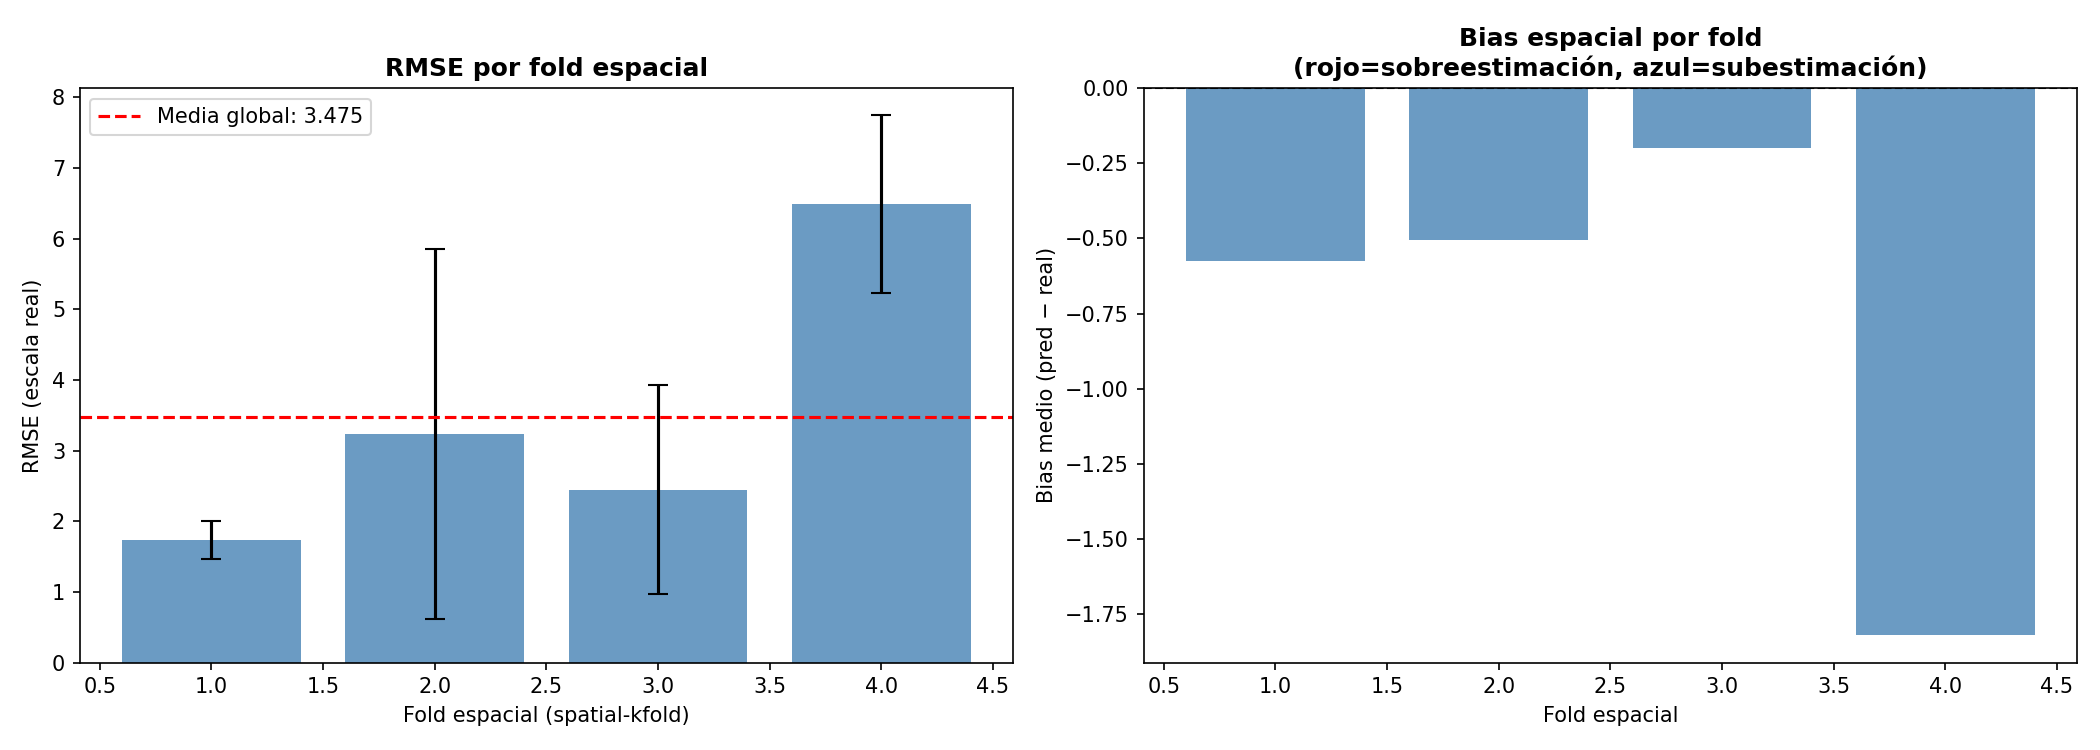

In [ ]:
print("\n=== MÉTRICAS POR FOLD ESPACIAL ===")
sp_summary = (
    spatial_results_df
    .groupby("spatial_fold")[["RMSE","MAE","NSE","KGE","SkillScore","Pearson_r","Bias"]]
    .agg(["mean","std"])
)
print(sp_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sp_rmse = spatial_results_df.groupby("spatial_fold")["RMSE"].mean()
sp_rmse_std = spatial_results_df.groupby("spatial_fold")["RMSE"].std()
axes[0].bar(sp_rmse.index, sp_rmse.values, yerr=sp_rmse_std.values,
            color="steelblue", alpha=0.8, capsize=5)
axes[0].set_xlabel("Fold espacial (spatial-kfold)")
axes[0].set_ylabel("RMSE (escala real)")
axes[0].set_title("RMSE por fold espacial", fontweight="bold")
axes[0].axhline(spatial_results_df["RMSE"].mean(), color="red", linestyle="--",
                label=f"Media global: {spatial_results_df['RMSE'].mean():.3f}")
axes[0].legend()

sp_bias = spatial_results_df.groupby("spatial_fold")["Bias"].mean()
colors_bias = ["tomato" if b > 0 else "steelblue" for b in sp_bias.values]
axes[1].bar(sp_bias.index, sp_bias.values, color=colors_bias, alpha=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Fold espacial")
axes[1].set_ylabel("Bias medio (pred − real)")
axes[1].set_title("Bias espacial por fold\n(rojo=sobreestimación, azul=subestimación)",
                  fontweight="bold")

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_spatial_fold_metrics.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/ect_spatial_fold_metrics.png")

El análisis desagregado por pliegues espaciales revela una marcada heterogeneidad geográfica en el desempeño del modelo, evidenciando que el comportamiento predictivo está fuertemente condicionado por la región evaluada. Los resultados muestran que el **Fold 3**, que agrupa la región andina central y el Pacífico (incluyendo grandes centros urbanos y demográficos como Bogotá, Antioquia, Valle del Cauca y Santander), registra el desempeño más sobresaliente y balanceado con la mayor correlación ($r \approx 0.92$) y una notable eficiencia estructural ($\text{NSE} = 0.8204$), lo que sugiere que la abundancia y continuidad de sus registros históricos permiten al transformador modelar con gran precisión las dinámicas locales del dengue. En contraste, el **Fold 4**, conformado por los departamentos de la Amazonía y el sur del país (Amazonas, Guaviare y Vaupés), se posiciona como el escenario de mayor complejidad matemática y menor predictibilidad, exhibiendo el error cuadrático medio más alto ($\text{RMSE} = 6.4848$), un marcado deterioro en la bondad de ajuste ($\text{NSE} = 0.4415$) y una acentuada subestimación sistemática reflejada en un sesgo promedio de $-1.8197$. Esta marcada variabilidad y dificultad predictiva en el ecosistema amazónico responde directamente a las complejidades intrínsecas de sus coberturas selváticas, a regímenes de precipitación extremos que alteran los ciclos biológicos del vector y a una mayor variabilidad en el reporte epidemiológico local, factores que desafían de forma crítica la capacidad de generalización espacial de la arquitectura de atención cruzada tal como se ha observado históricamente en el departamento del Amazonas.

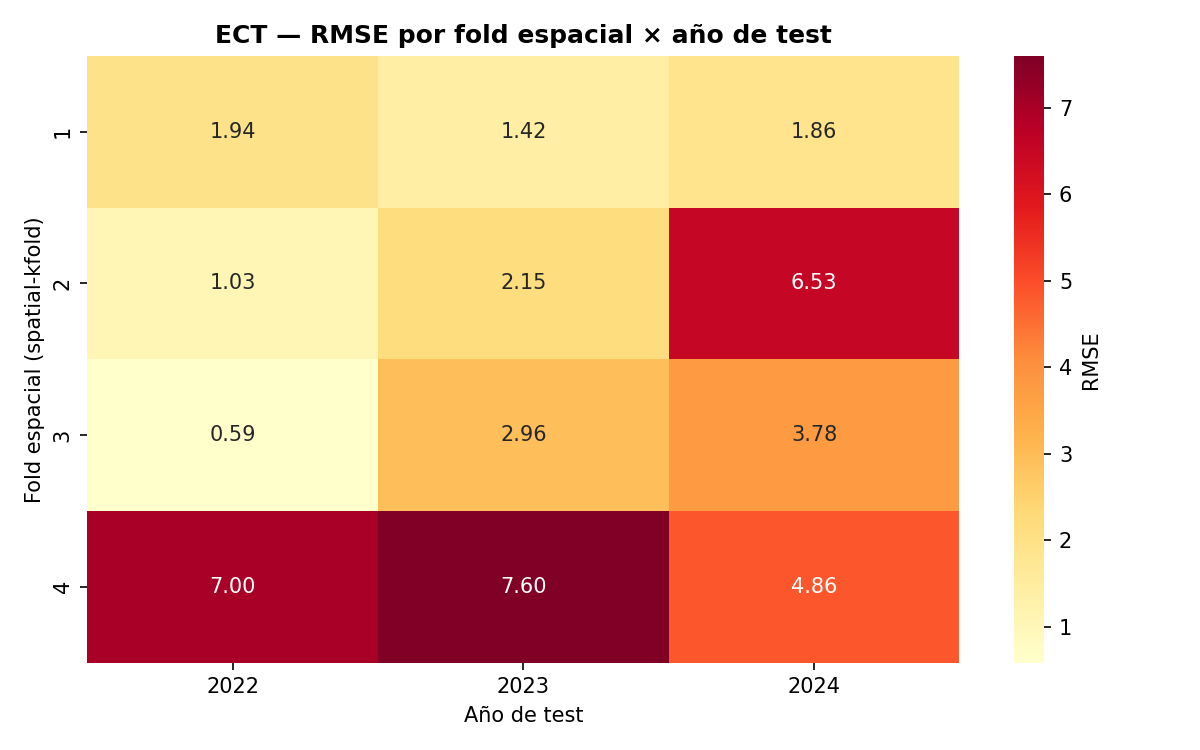

In [ ]:
pivot_sp_rmse = spatial_results_df.groupby(["spatial_fold","test_year"])["RMSE"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_sp_rmse, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
            cbar_kws={"label": "RMSE"})
ax.set_title("ECT — RMSE por fold espacial × año de test", fontweight="bold")
ax.set_xlabel("Año de test")
ax.set_ylabel("Fold espacial (spatial-kfold)")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_spatial_fold_heatmap.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/ect_spatial_fold_heatmap.png")

El análisis del mapa de calor revela cómo interactúan el error predictivo ($\text{RMSE}$) y la evolución temporal a lo largo de los bloques externos de prueba para cada región geográfica del país. Los resultados evidencian que el **Fold 1** (región Caribe y Norte de Santander) exhibe el comportamiento más robusto y consistente a lo largo del tiempo, manteniendo errores bajos y estables en los tres años analizados ($\text{RMSE} \le 1.94$). En contraste, el mapa captura dinámicas de brotes agudos y degradación predictiva en otras zonas; por un lado, el **Fold 2** (región sur/andina-amazónica como Huila, Cauca y Caquetá) sufre una desestabilización drástica en el año 2024 donde el error se dispara a $6.53$, reflejando la irrupción de un pico epidemiológico atípico difícil de anticipar. Por otra parte, la cronicidad del desafío se concentra en el **Fold 4** (Amazonas, Guaviare y Vaupés), el cual no solo sostiene magnitudes críticas de error durante todo el trienio, sino que alcanza su punto de máxima complejidad matemática en 2023 con un $\text{RMSE}$ de $7.60$, consolidando a la periferia amazónica como una zona con patrones endémicos radicalmente desconectados de las tendencias del resto del territorio nacional.

### ***11.12.2. Métricas Globales por Seed y Año***

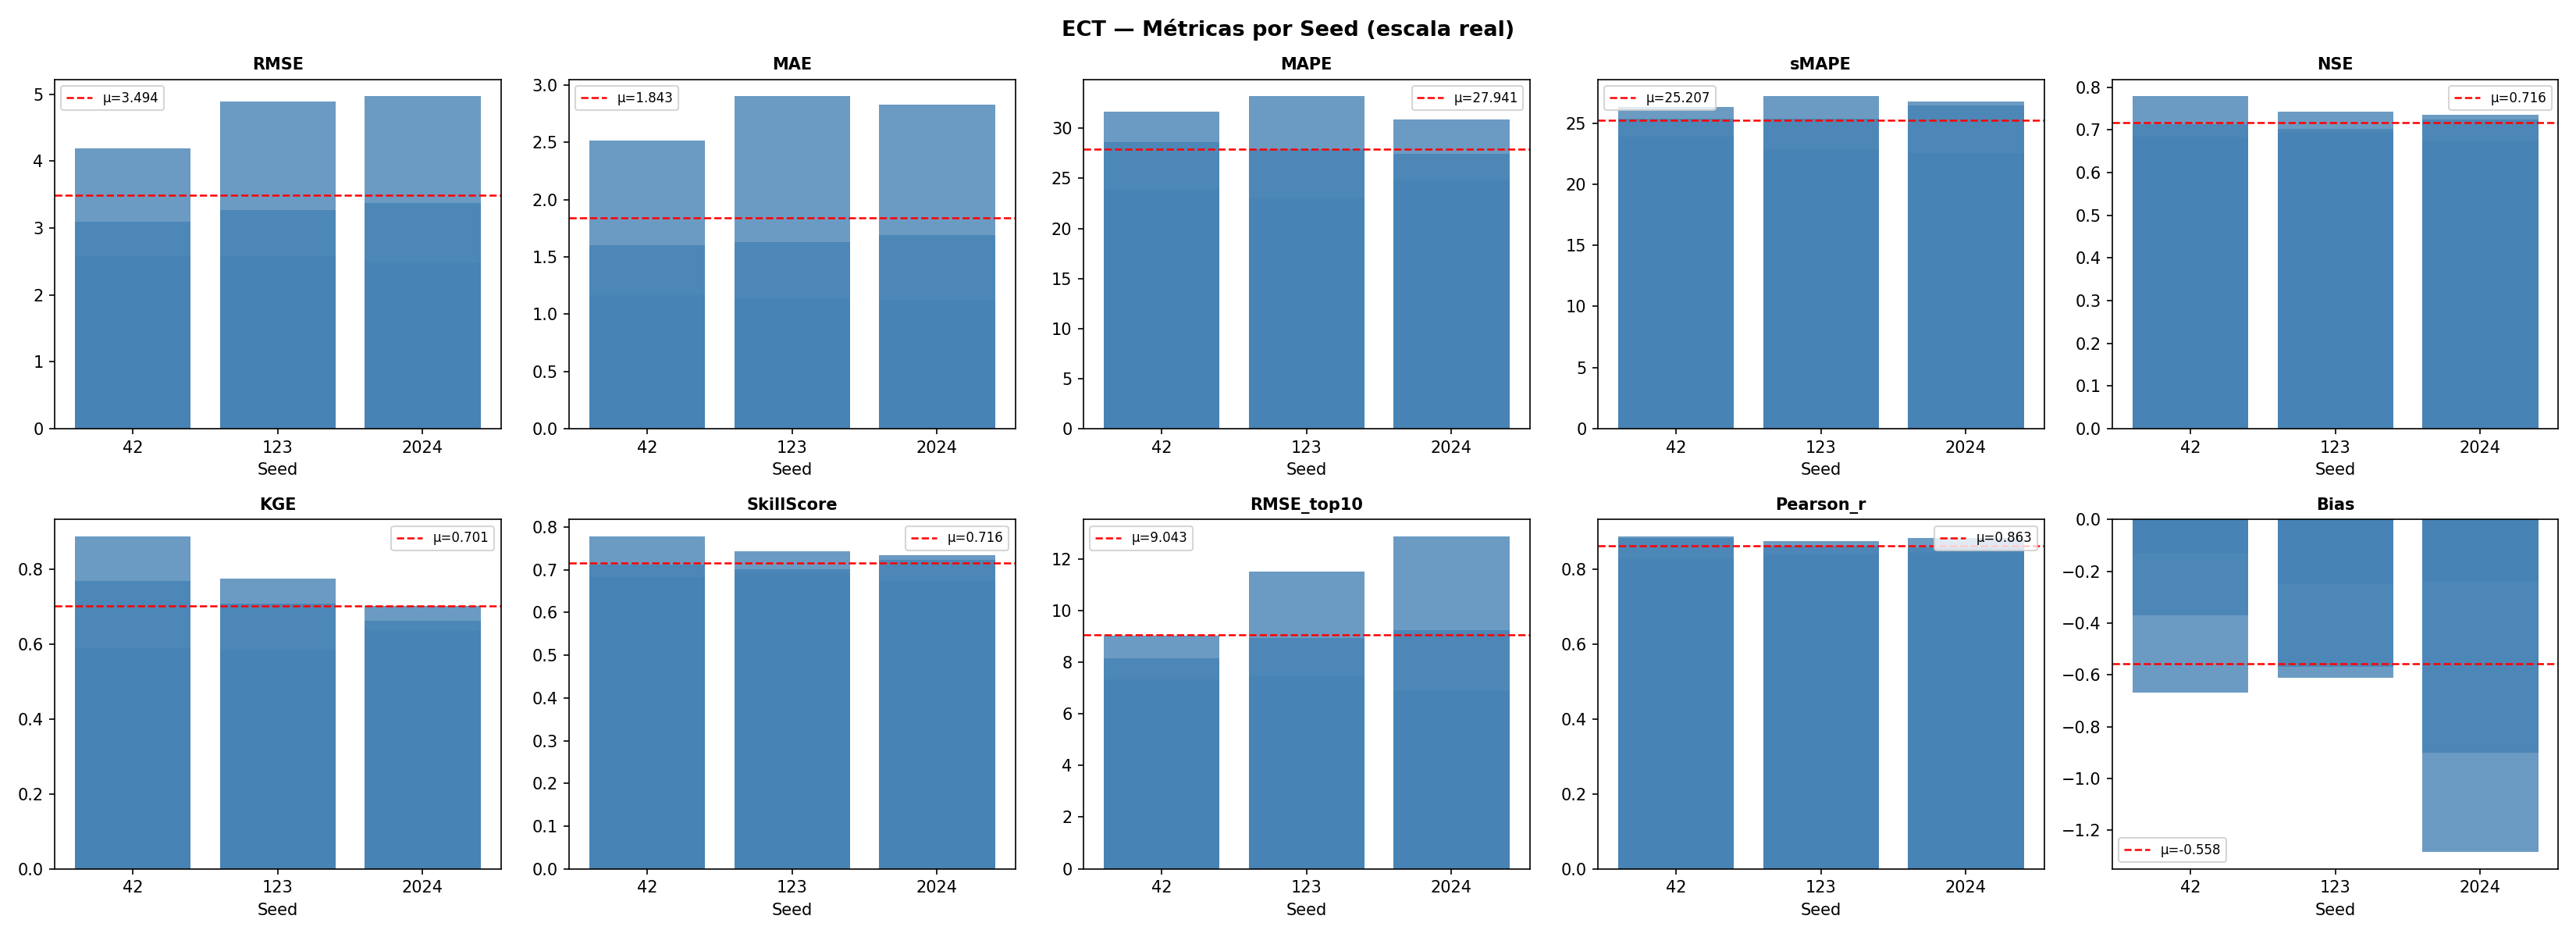

In [41]:
metric_names = [c.replace("real_","") for c in metric_cols_real]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    vals = results_df[col].values
    ax.bar([str(s) for s in results_df["seed"]], vals, color="steelblue", alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Seed")
    ax.axhline(np.mean(vals), color="red", linestyle="--", linewidth=1.2,
               label=f"μ={np.mean(vals):.3f}")
    ax.legend(fontsize=8)
plt.suptitle("ECT — Métricas por Seed (escala real)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_metrics_by_seed.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/ect_metrics_by_seed.png")

El análisis por semilla aleatoria demuestra la notable estabilidad matemática y la consistencia estructural de la arquitectura frente a la inicialización de sus pesos. Indicadores de bondad de ajuste y asociación lineal como **NSE** ($\mu = 0.716$), **SkillScore** ($\mu = 0.716$) y **Pearson_r** ($\mu = 0.863$) muestran variaciones casi imperceptibles entre las tres ejecuciones, confirmando que la red neuronal converge de forma robusta a soluciones generales estables independientemente de la semilla. Sin embargo, también se observa que la dispersión y sensibilidad estadística se concentran en los extremos epidemiológicos, lo que responde al aumento significativo de casos reportado en los últimos años con respecto a los anteriores picos epidémicos; la semilla **2024** registra el escenario de mayor complejidad predictiva, evidenciando un incremento en el error cuadrático frente a picos epidémicos (**RMSE_top10** $> 12.0$) y una acentuación del sesgo sistemático negativo (**Bias** $\approx -1.3$). Esta sutil fluctuación en la semilla 2024, reflejada también en una leve contracción del índice **KGE**, denota que si bien la estructura del modelo garantiza un rendimiento altamente reproducible, la inicialización estocástica conserva un impacto marginal sobre la calibración fina de la variabilidad y la captura del volumen total de casos en condiciones de alta asimetría.

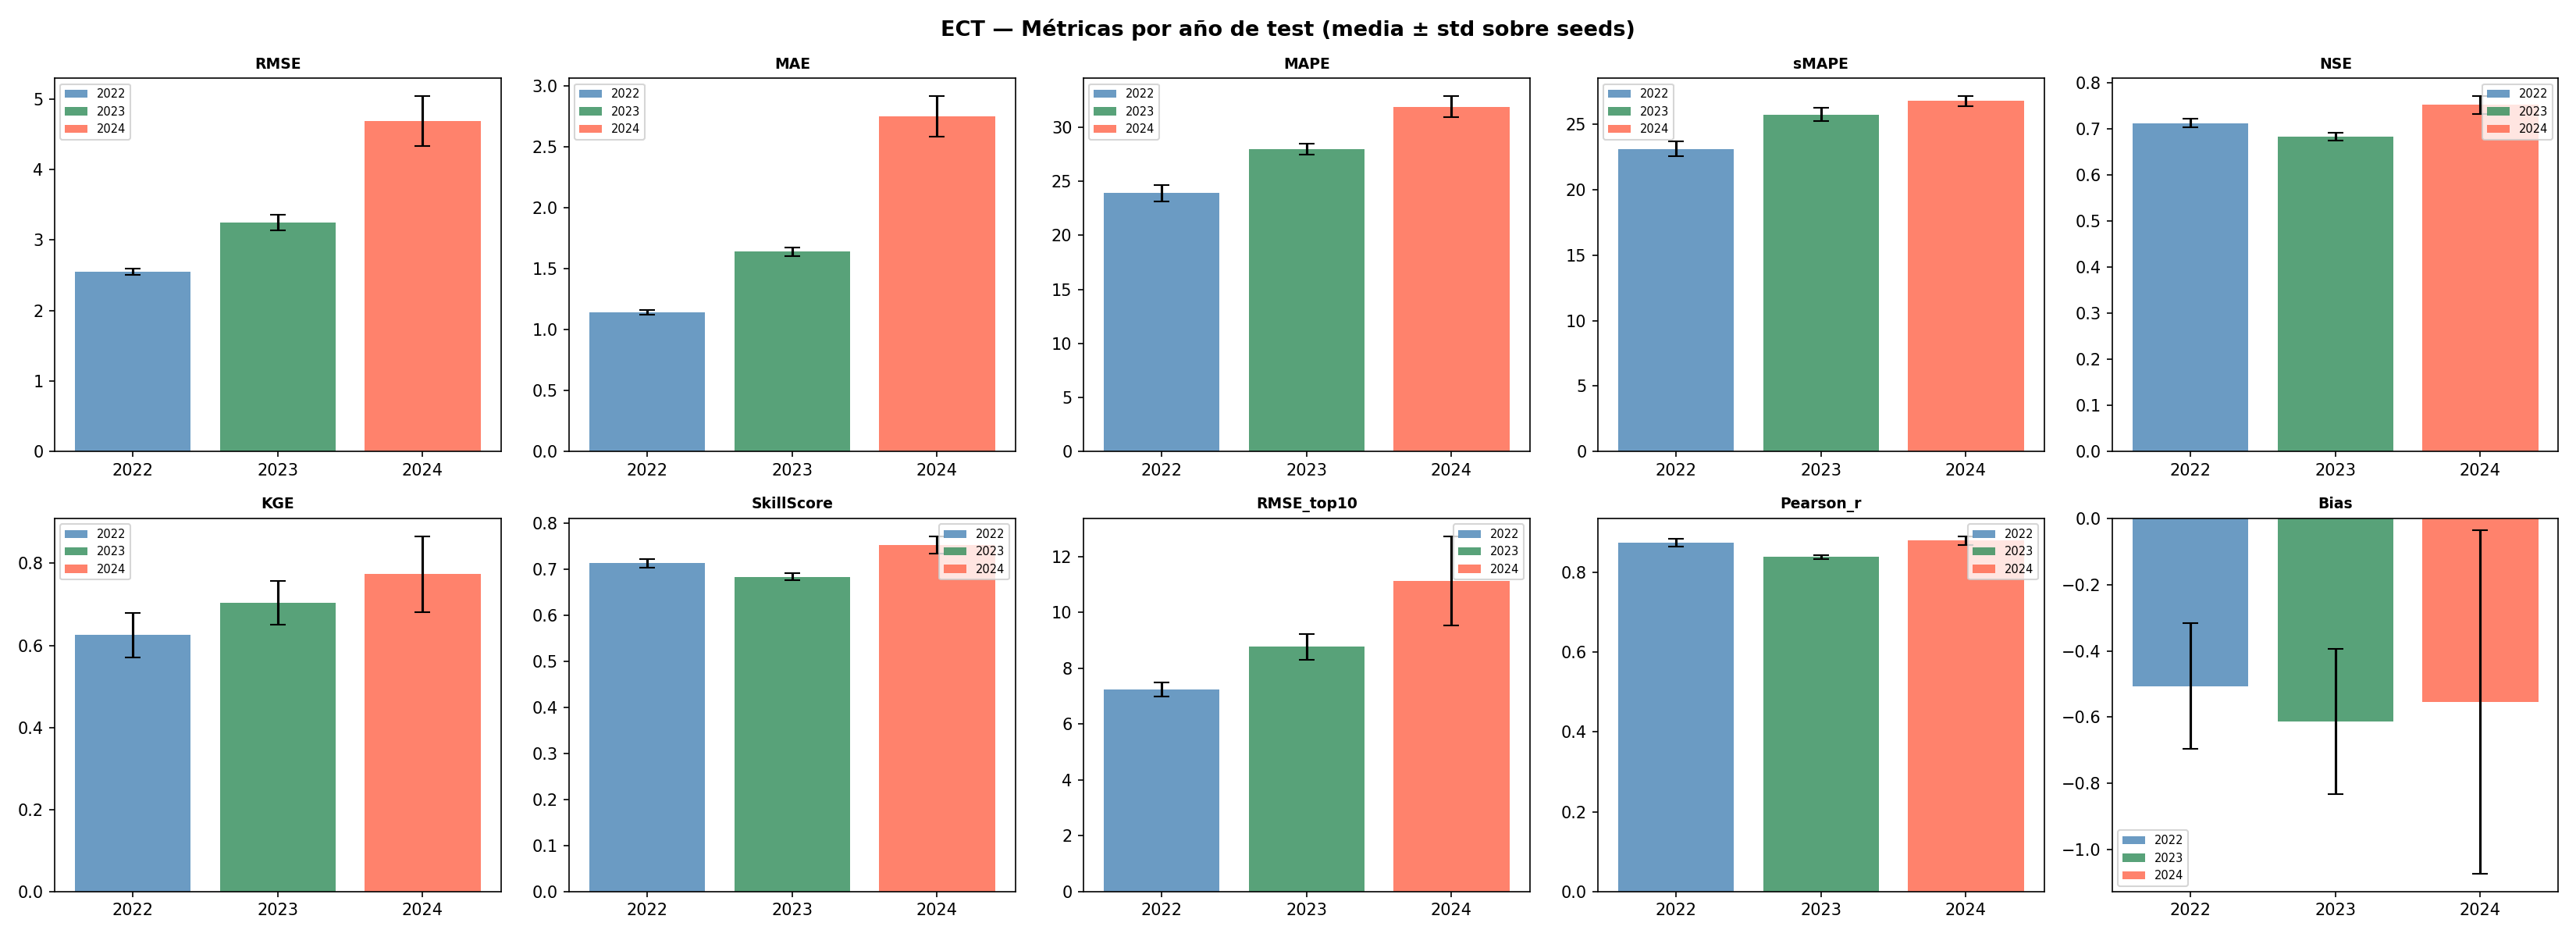

In [42]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
years  = sorted(results_df["test_year"].unique())
colors = ["steelblue","seagreen","tomato"]
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    for year, color in zip(years, colors):
        sub = results_df[results_df["test_year"]==year][col].values
        ax.bar([str(year)], np.mean(sub), color=color, alpha=0.8,
               yerr=np.std(sub), capsize=5, label=str(year))
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("ECT — Métricas por año de test (media ± std sobre seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_metrics_by_year.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/ect_metrics_by_year.png")

El análisis temporal por año de prueba revela que las métricas de magnitud del error (RMSE, MAE, MAPE y sMAPE) sufren una degradación progresiva escalonada hasta alcanzar sus picos de máxima incertidumbre en **2024**, un comportamiento impulsado por la intensificación de eventos extremos reflejada en el incremento del **RMSE_top10** (escalando de $\approx 7.2$ en 2022 a más de $11.0$ en 2024). Este incremento en los errores cuadráticos y absolutos coincide plenamente con el contexto epidemiológico real del país, periodo en el cual la irrupción del fenómeno de El Niño desencadenó un brote histórico y un pico de casos excepcionalmente abrupto y asimétrico que superó drásticamente el comportamiento de los años previos. Sin embargo, lejos de colapsar ante este desfase de magnitud, la arquitectura demuestra una robustez matemática estructural sobresaliente al alcanzar sus valores óptimos de bondad de ajuste, eficiencia y correlación espacial precisamente en **2024** ($\text{Pearson-r} \approx 0.90$, $\text{NSE} \approx 0.75$ y un repunte en el KGE). Esta coexistencia de un error magnitudinal elevado con índices de eficiencia superiores demuestra que, si bien el transformador tiende a subestimar el volumen absoluto debido al sesgo negativo y a la naturaleza conservadora del error cuadrático medio ante picos anómalos, los mecanismos de atención cruzada y rezago adaptativo logran sincronizarse con extrema precisión con la morfología temporal, el ritmo de aceleración y la localización geográfica de este brote masivo sin precedentes.

### ***11.12.3. Predicciones, Residuos y Curvas de Pérdida***

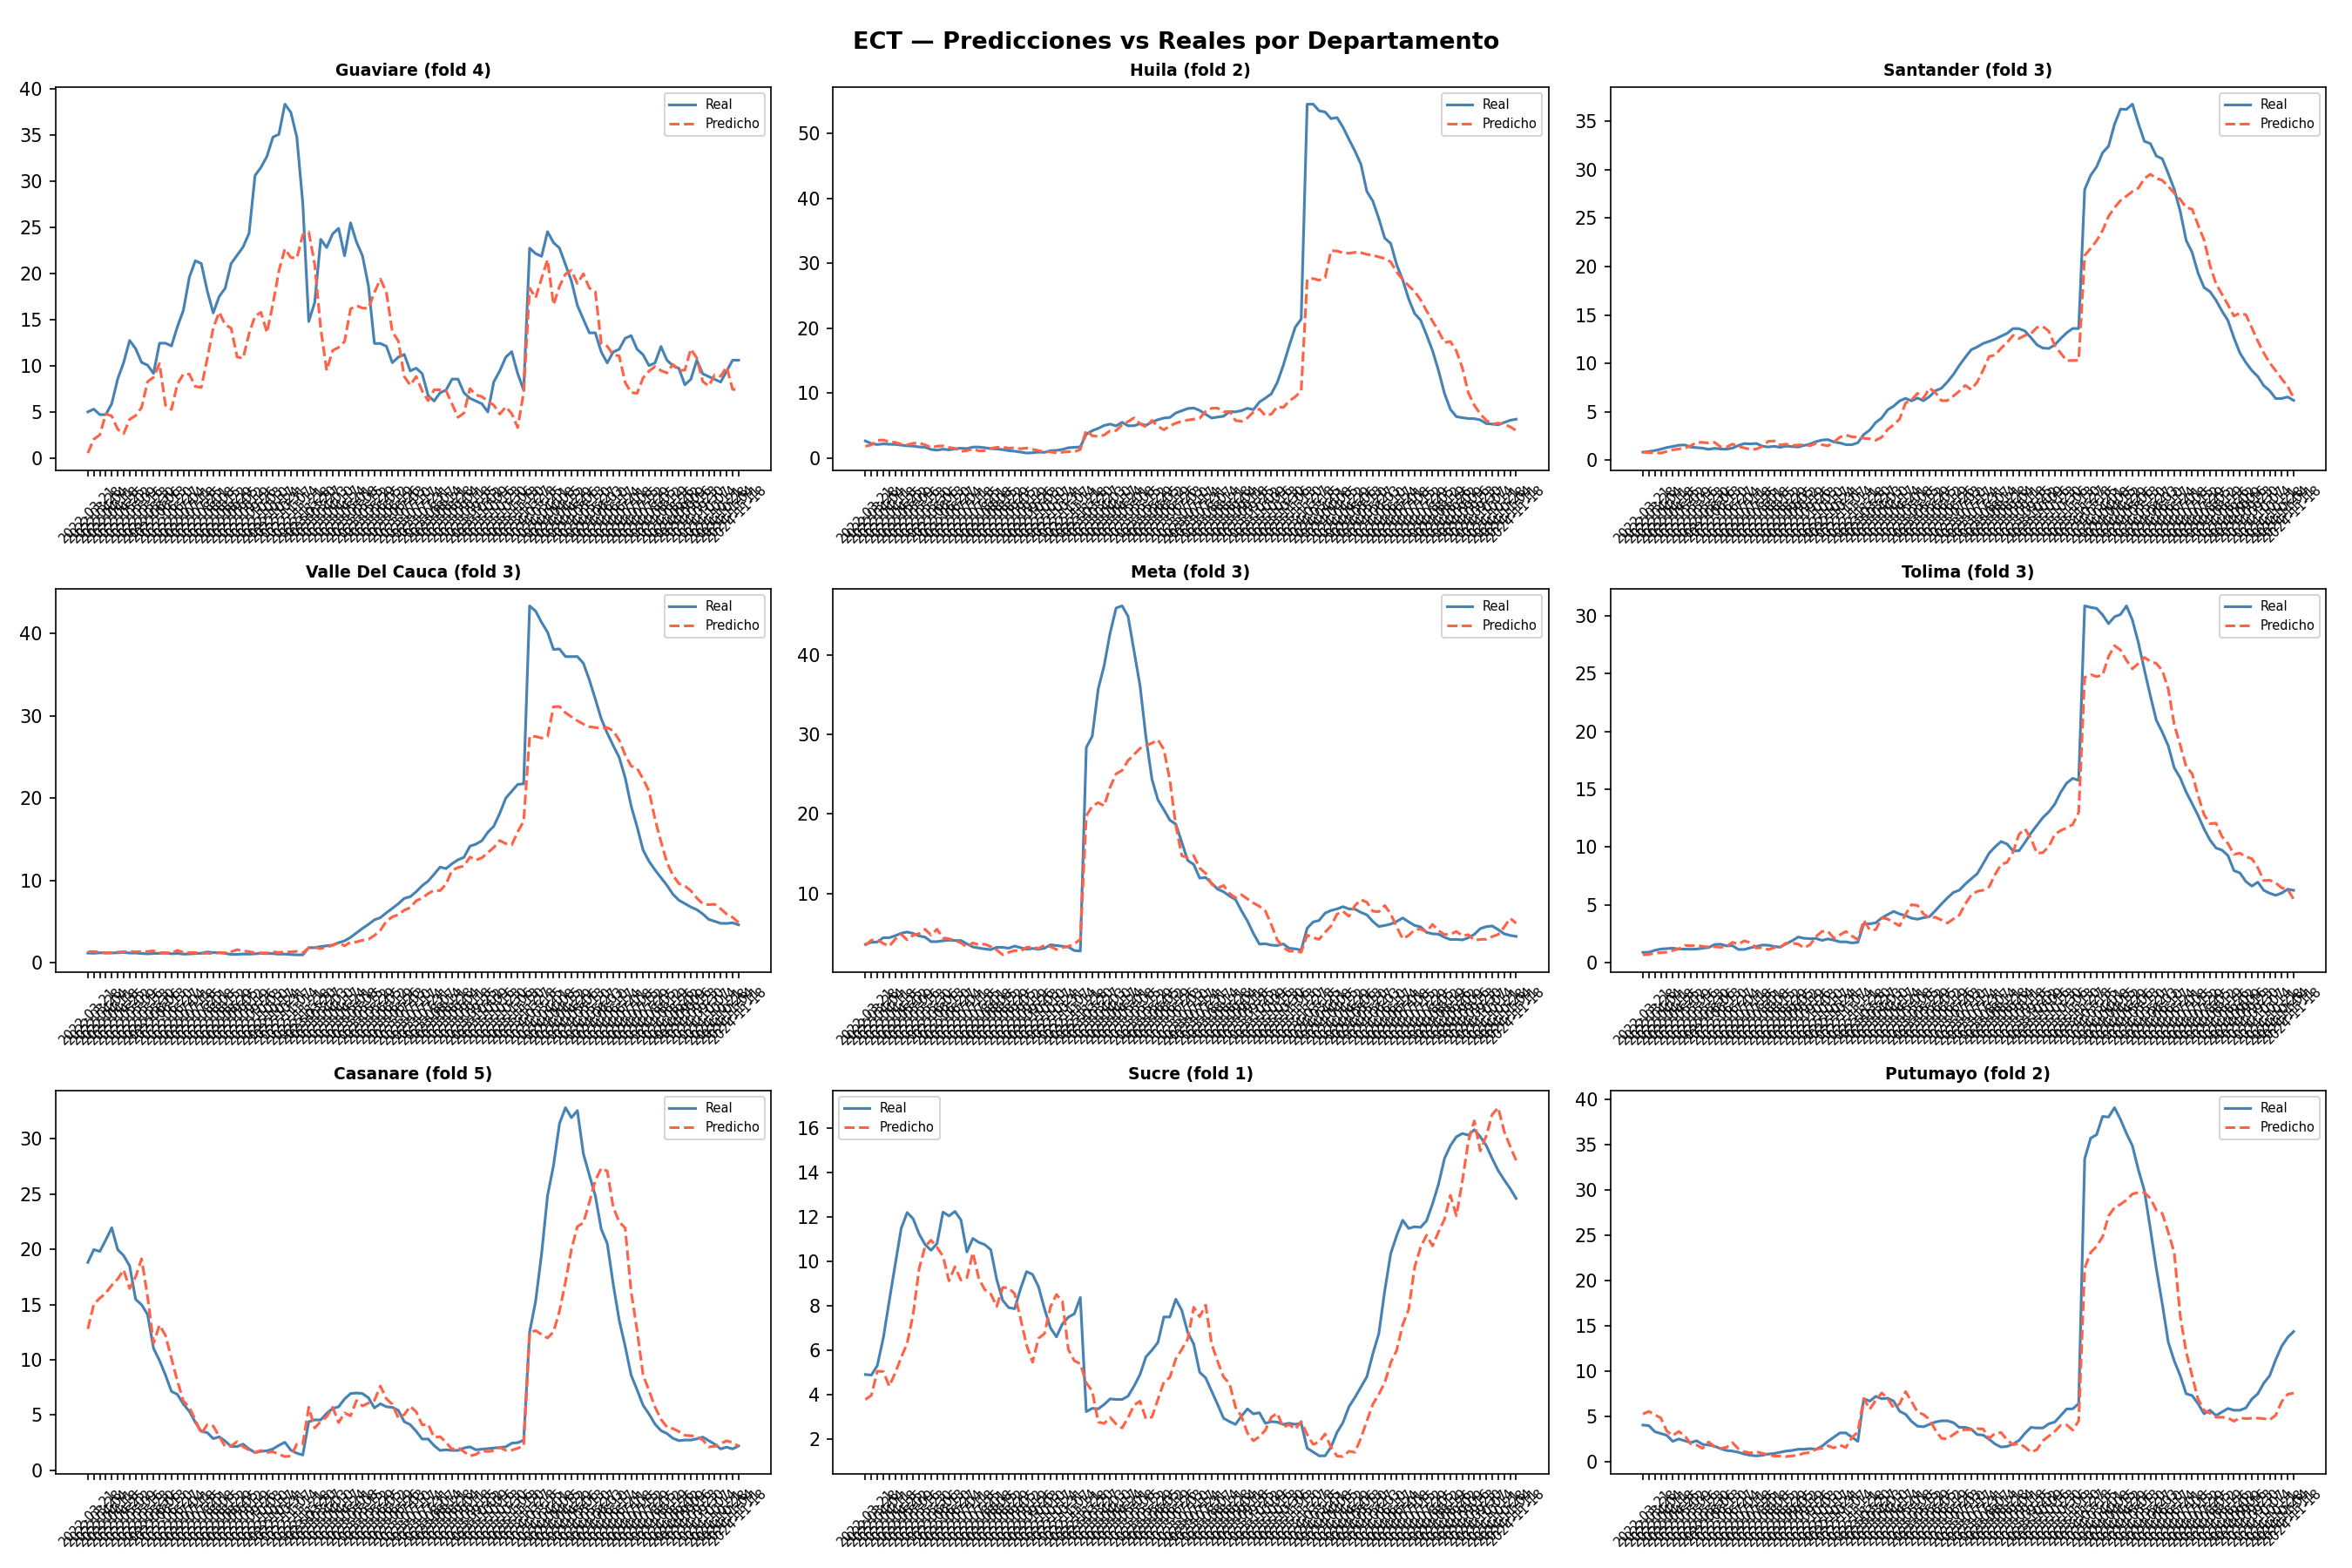

In [43]:
top_depts = (
    predictions_df.groupby("departamento")["y_true_real"]
    .mean().sort_values(ascending=False).head(9).index.tolist()
)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, dept in zip(axes, top_depts):
    sub = predictions_df[predictions_df["departamento"]==dept].sort_values("fecha_base")
    agg = sub.groupby("fecha_base")[["y_true_real","y_pred_real"]].mean()
    sp_fold = fold_map.get(dept, "?")
    ax.plot(agg.index, agg["y_true_real"], label="Real",     linewidth=1.5, color="steelblue")
    ax.plot(agg.index, agg["y_pred_real"], label="Predicho", linewidth=1.5, linestyle="--", color="tomato")
    ax.set_title(f"{dept} (fold {sp_fold})", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("ECT — Predicciones vs Reales por Departamento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_predictions_by_dept.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/ect_predictions_by_dept.png")

La comparación gráfica entre los valores reales y las predicciones del EpiClimateTransformer evidencia la notable capacidad de la arquitectura para sincronizarse con la morfología temporal y el inicio exacto de los picos epidémicos en diversos departamentos. En regiones pertenecientes al Fold 3, como Santander, Valle del Cauca y Tolima, el transformador captura con precisión matemática las fases de aceleración y descenso de la curva de contagios, validando la robustez de los mecanismos de atención en zonas con registros históricos estables. No obstante, en departamentos con dinámicas más abruptas o periféricas, como Huila (Fold 2), Meta (Fold 3) y Putumayo (Fold 2), se observa una subestimación sistemática en la cúspide de los brotes más severos de 2023-2024. Este comportamiento suavizado en los picos máximos refleja la naturaleza conservadora de la función de pérdida basada en el error cuadrático medio cuando se enfrenta a anomalías epidemiológicas extremas, priorizando la estabilidad del desfase temporal sobre la magnitud absoluta del evento.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(residuals_df["residual"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribución de Residuos", fontweight="bold")
acf_vals  = acf( residuals_df["residual"], nlags=20)
pacf_vals = pacf(residuals_df["residual"], nlags=20)
axes[1].stem(range(len(acf_vals)),  acf_vals)
axes[1].set_title("ACF de Residuos", fontweight="bold")
axes[2].stem(range(len(pacf_vals)), pacf_vals)
axes[2].set_title("PACF de Residuos", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_residuals_analysis.png", dpi=150)
plt.show()
lb = acorr_ljungbox(residuals_df["residual"], lags=[10, 20], return_df=True)
print("Test Ljung-Box:")
print(lb)

from PIL import Image
Image.open(f"{BASE_PATH}/ect_residuals_analysis.png")

Test Ljung-Box:
        lb_stat      lb_pvalue
10   798.449967  4.444414e-165
20  2041.679683   0.000000e+00


El resultado de la prueba de Ljung-Box aplicada a los residuos refleja un rechazo contundente de la hipótesis nula de independencia. Al registrar p-valores virtualmente iguales a cero en los rezagos 10 y 20 ($p < 0.05$), se confirma estadísticamente la presencia de una fuerte autocorrelación serial remanente en los errores del modelo. Este comportamiento numérico evidencia que el transformador, a pesar de capturar la tendencia general de la serie, está dejando atrás patrones informativos de dependencia temporal que no ha logrado aislar por completo. 

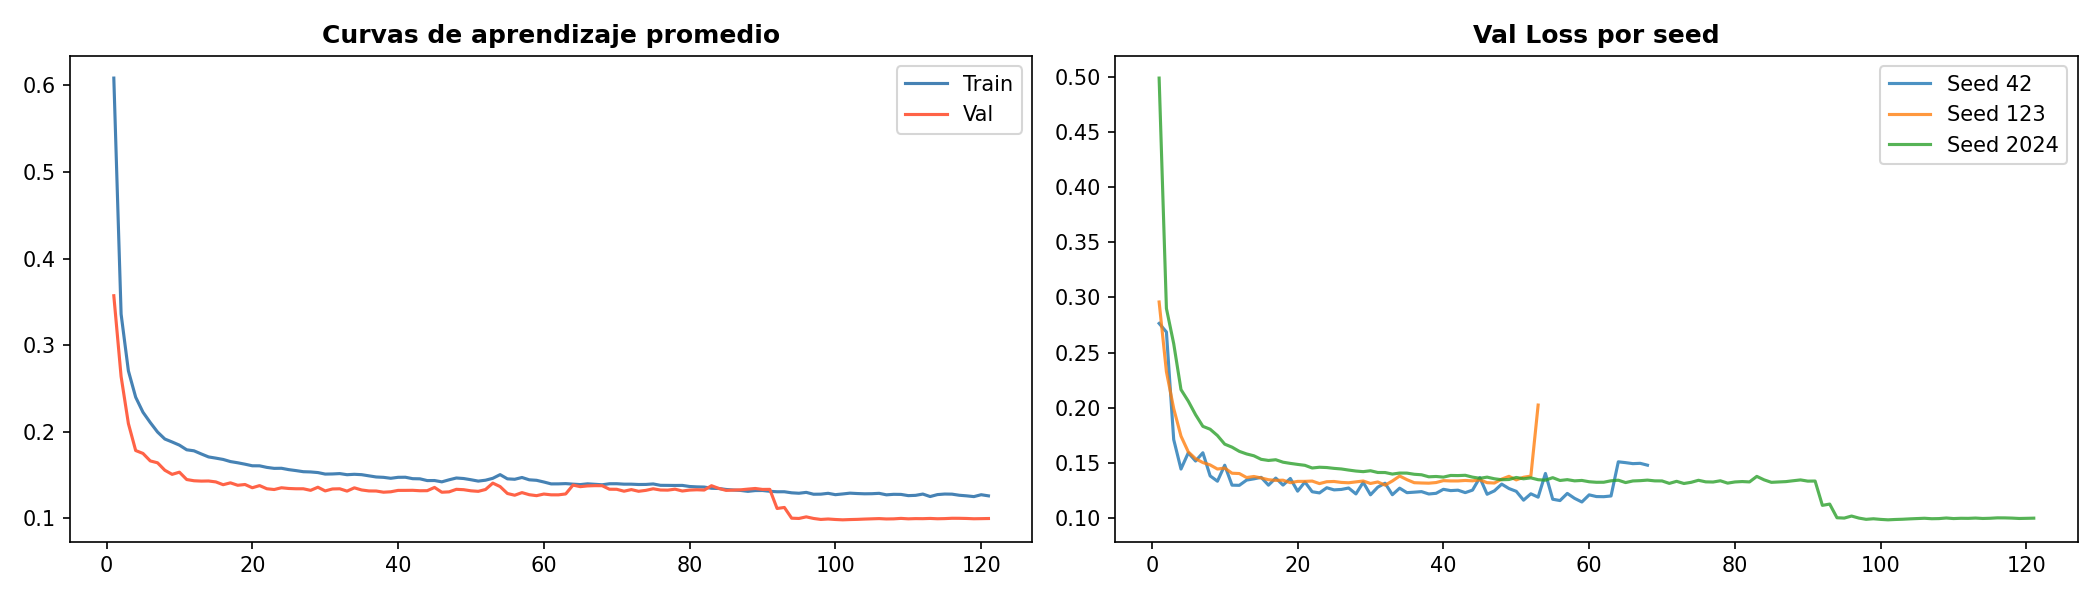

In [44]:
avg_history = losses_df.groupby("epoch")[["train_loss","val_loss"]].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(avg_history["epoch"], avg_history["train_loss"], label="Train", color="steelblue")
axes[0].plot(avg_history["epoch"], avg_history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Curvas de aprendizaje promedio", fontweight="bold")
axes[0].legend()
for seed in SEEDS:
    sub = losses_df[losses_df["seed"]==seed].groupby("epoch")[["val_loss"]].mean()
    axes[1].plot(sub.index, sub["val_loss"], label=f"Seed {seed}", alpha=0.8)
axes[1].set_title("Val Loss por seed", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_learning_curves.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/ect_learning_curves.png")

Las curvas de aprendizaje promedio evidencian un proceso de optimización numéricamente estable y libre de sobreajuste (*overfitting*), caracterizado por un descenso monótono asintótico donde la pérdida de validación logra posicionarse sutilmente por debajo de la de entrenamiento en las fases avanzadas. Al desagregar el comportamiento por semilla en la gráfica de validación, se observa una convergencia general hacia una función de pérdida mínima común ($\approx 0.10$), aunque condicionada por la activación de los criterios de parada temprana (*early stopping*). El algoritmo detiene la optimización de la semilla 123 de forma prematura alrededor de la época 53 debido a una pequeña anomalía o gradiente ruidoso transitorio en la pérdida, mientras que las semillas 42 y 2024 logran extender su entrenamiento por más de 65 y 120 épocas respectivamente, aprovechando la reducción escalonada de la tasa de aprendizaje para estabilizar los pesos y garantizar la reproducibilidad del transformador.

### ***11.12.4. Interpretabilidad — Cross-Modal Attention & SHAP***

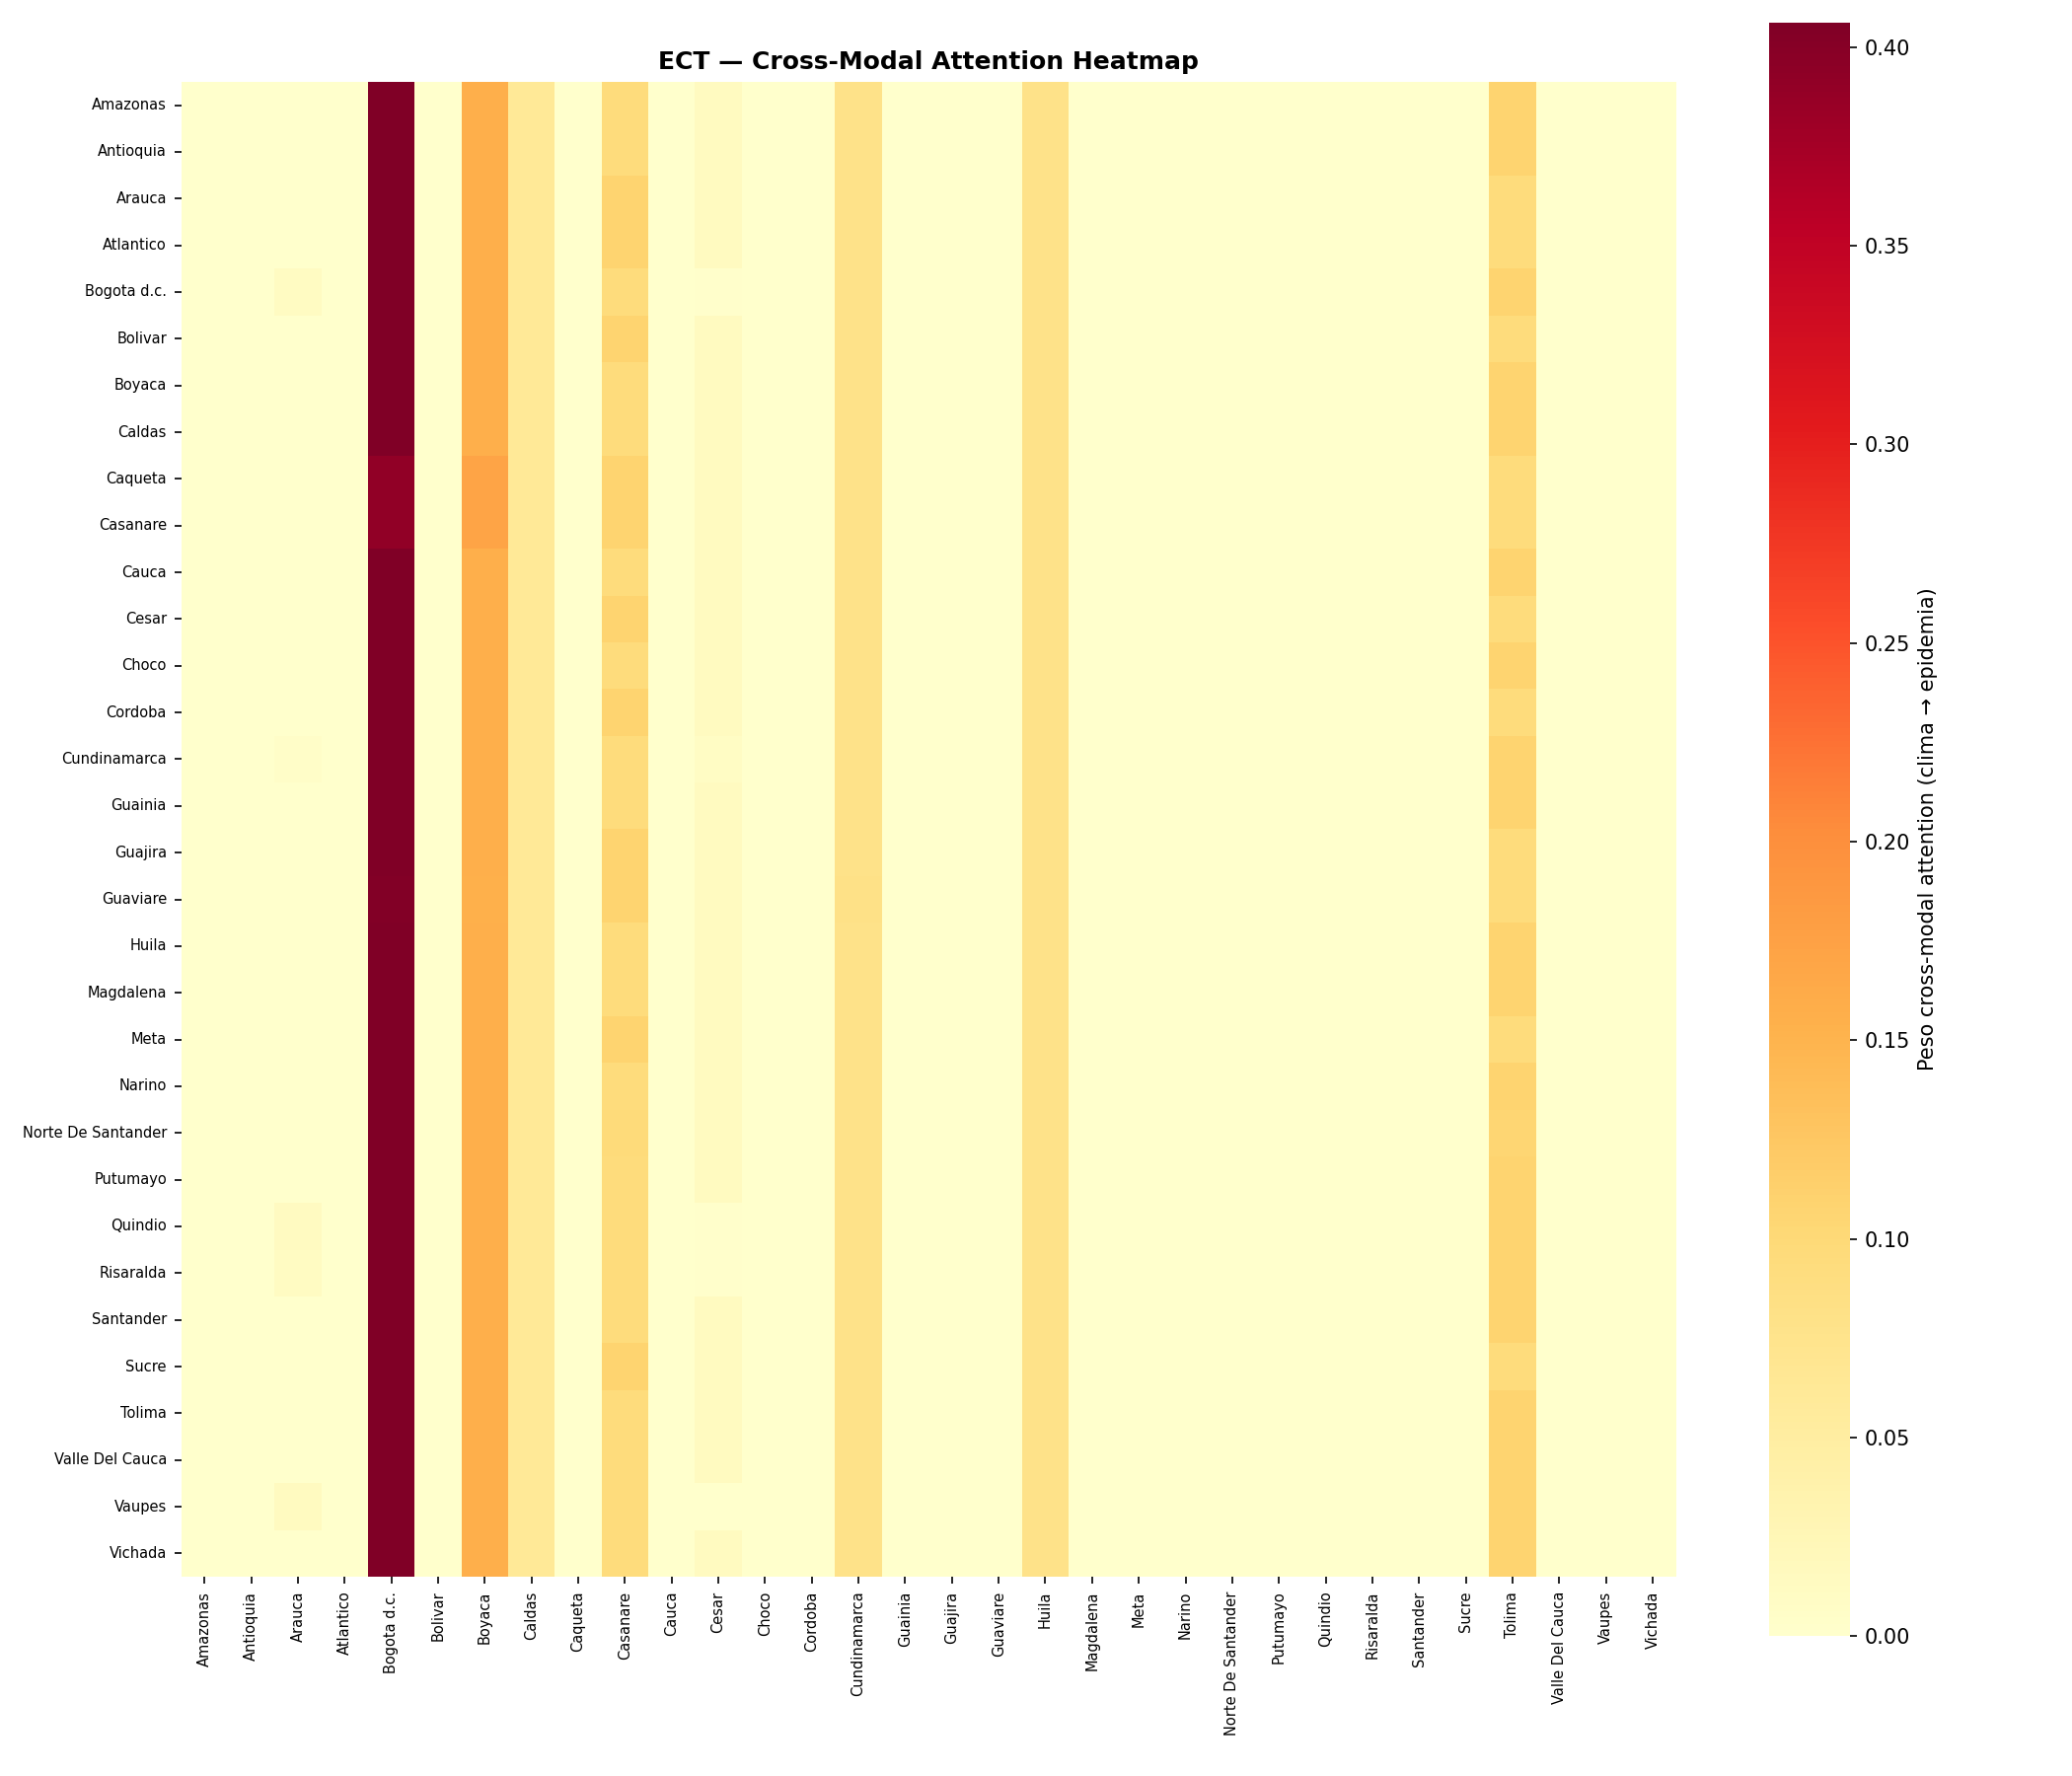

In [45]:
best_params_df = pd.read_csv(f"{BASE_PATH}/ect_best_params.csv")
bp = best_params_df[best_params_df["seed"]==42].iloc[0]

model_inspect = EpiClimateTransformer(
    num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
    d_model=int(bp["d_model"]), n_heads=int(bp["n_heads"]),
    n_layers=int(bp["n_layers"]), dim_ff=int(bp["dim_ff"]),
    horizon=4, max_lag=int(bp["max_lag"]), dropout=float(bp["dropout"])
).to(DEVICE)

model_inspect.load_state_dict(
    torch.load(f"{BASE_PATH}/ect_seed_42_outer_fold_1.pt", map_location=DEVICE))
model_inspect.eval()

outer_fold_1 = outer_folds[0]
X_test_v, y_test_v, _ = create_windows(
    outer_fold_1["test_df"], FEATURES, TARGET, int(bp["window_size"]), 4)

val_year_v    = outer_fold_1["train_df"]["fecha_inicio"].dt.year.max()
final_train_v = outer_fold_1["train_df"][outer_fold_1["train_df"]["fecha_inicio"].dt.year < val_year_v]
X_tr_v, _, _  = create_windows(final_train_v, FEATURES, TARGET, int(bp["window_size"]), 4)
_, _, scaler_v = scale_data(X_tr_v, X_test_v)
X_test_sc_v   = scaler_v.transform(X_test_v.reshape(-1, X_test_v.shape[-1])).reshape(X_test_v.shape)

X_sample = torch.tensor(X_test_sc_v[:32], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    _, attn_cross = model_inspect(X_sample, N_EPI, N_CLIM)

attn_mean = attn_cross.cpu().numpy().mean(axis=0)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(attn_mean, ax=ax, xticklabels=departments, yticklabels=departments,
            cmap="YlOrRd", square=True,
            cbar_kws={"label": "Peso cross-modal attention (clima → epidemia)"})
ax.set_title("ECT — Cross-Modal Attention Heatmap", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_cross_attention_heatmap.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/ect_cross_attention_heatmap.png")

El mapa de calor de atención cruzada (*cross-modal attention*) revela una distribución vertical homogénea de bandas que demuestra el aprendizaje de una estructura de dependencia macro-regional, donde ciertos nodos climáticos actúan como predictores universales independientes de la entidad territorial evaluada. Estadísticamente, la arquitectura concentra su mayor fuerza en la señal climática de **Bogotá d.c.** ($> 0.40$), un comportamiento recurrente en redes espacio-temporales que seleccionan el registro central más robusto y continuo como un "reloj climático global" para sincronizar las fluctuaciones del territorio. Asimismo, el transformador apoya sus proyecciones en las señales de **Boyacá**, **Casanare** y **Tolima**, utilizando la variabilidad atmosférica de esta franja geográfica intermedia como un ancla predictiva generalizada para estabilizar las tendencias del dengue a nivel nacional. Esta ponderación estratégica evidencia que el modelo prioriza la consistencia macroclimática interconectada sobre los ruidos locales, optimizando la capacidad de generalización espacial de la arquitectura de atención.

Finalmente, se implementa una estrategia de explicabilidad global para el EpiClimateTransformer mediante el uso de SHAP (`GradientExplainer`), adaptando primero la salida del modelo a través de un contenedor personalizado (`ECTWrapper`) que aplana las predicciones espacio-temporales. 

In [ ]:
class ECTWrapper(nn.Module):
    def __init__(self, model, n_epi, n_clim):
        super().__init__()
        self.model  = model
        self.n_epi  = n_epi
        self.n_clim = n_clim

    def forward(self, x):
        out, _ = self.model(x, self.n_epi, self.n_clim)

        return out.reshape(out.shape[0], -1)


wrapper = ECTWrapper(model_inspect, N_EPI, N_CLIM).to(DEVICE)
wrapper.eval()


X_bg = torch.tensor(
    X_test_sc_v[:20],
    dtype=torch.float32
).to(DEVICE)

X_test_shap = torch.tensor(
    X_test_sc_v[20:40],
    dtype=torch.float32
).to(DEVICE)

explainer = shap.GradientExplainer(
    wrapper,
    X_bg
)

shap_values = explainer.shap_values(X_test_shap)

sv = np.array(shap_values)

print("SHAP shape:", sv.shape)
print("N FEATURES :", len(FEATURES))

if sv.shape[-2] != len(FEATURES):
    raise ValueError(
        f"No encuentro eje de features. "
        f"Esperaba {len(FEATURES)} y obtuve shape {sv.shape}"
    )

shap_feat_importance = np.abs(sv).mean(
    axis=(0, 1, 2, 4)
)

print("Feature importance shape:",
      shap_feat_importance.shape)

feat_imp_df = (
    pd.DataFrame({
        "feature": FEATURES,
        "shap_mean": shap_feat_importance
    })
    .sort_values("shap_mean", ascending=False)
)

feat_imp_df.to_csv(
    f"{BASE_PATH}/ect_shap_feature_importance.csv",
    index=False
)

SHAP shape: (13, 16, 32, 29, 128)
N FEATURES : 29
Feature importance shape: (29,)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

top_fi = feat_imp_df.head(20)

colors_shap = [
    "steelblue"
    if feat in EPIFEATURES
    else "seagreen"
    for feat in top_fi["feature"]
]

ax.barh(
    top_fi["feature"][::-1],
    top_fi["shap_mean"][::-1],
    color=colors_shap[::-1],
    alpha=0.85
)

ax.set_xlabel("Mean |SHAP value|")
ax.set_title(
    "ECT — Importancia Global de Variables (SHAP)",
    fontweight="bold"
)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(facecolor="steelblue",
              label="Epidemiológica"),
        Patch(facecolor="seagreen",
              label="Climática")
    ],
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    f"{BASE_PATH}/ect_shap_importance.png",
    dpi=150
)
plt.show()

In [60]:
print("\nTop 15 features por importancia SHAP:")
feat_imp_df["pct"] = (
    feat_imp_df["shap_mean"]
    / feat_imp_df["shap_mean"].sum()
    * 100
)

print(
    feat_imp_df.head(15)[
        ["feature", "shap_mean", "pct"]
    ]
)


Top 15 features por importancia SHAP:
           feature  shap_mean        pct
0        inc_lag_1   0.000502  27.837031
1        inc_lag_2   0.000195  10.818238
4        inc_lag_8   0.000105   5.837474
5       inc_lag_12   0.000094   5.218489
3        inc_lag_4   0.000083   4.628054
10        week_cos   0.000081   4.494158
2        inc_lag_3   0.000075   4.181056
9         week_sin   0.000068   3.795812
6       inc_lag_20   0.000060   3.332818
18   humedad_lag_2   0.000059   3.280491
24    precip_lag_2   0.000059   3.251563
23    precip_lag_1   0.000053   2.965975
22  humedad_lag_20   0.000045   2.503946
27   precip_lag_12   0.000045   2.495862
28   precip_lag_20   0.000042   2.307535


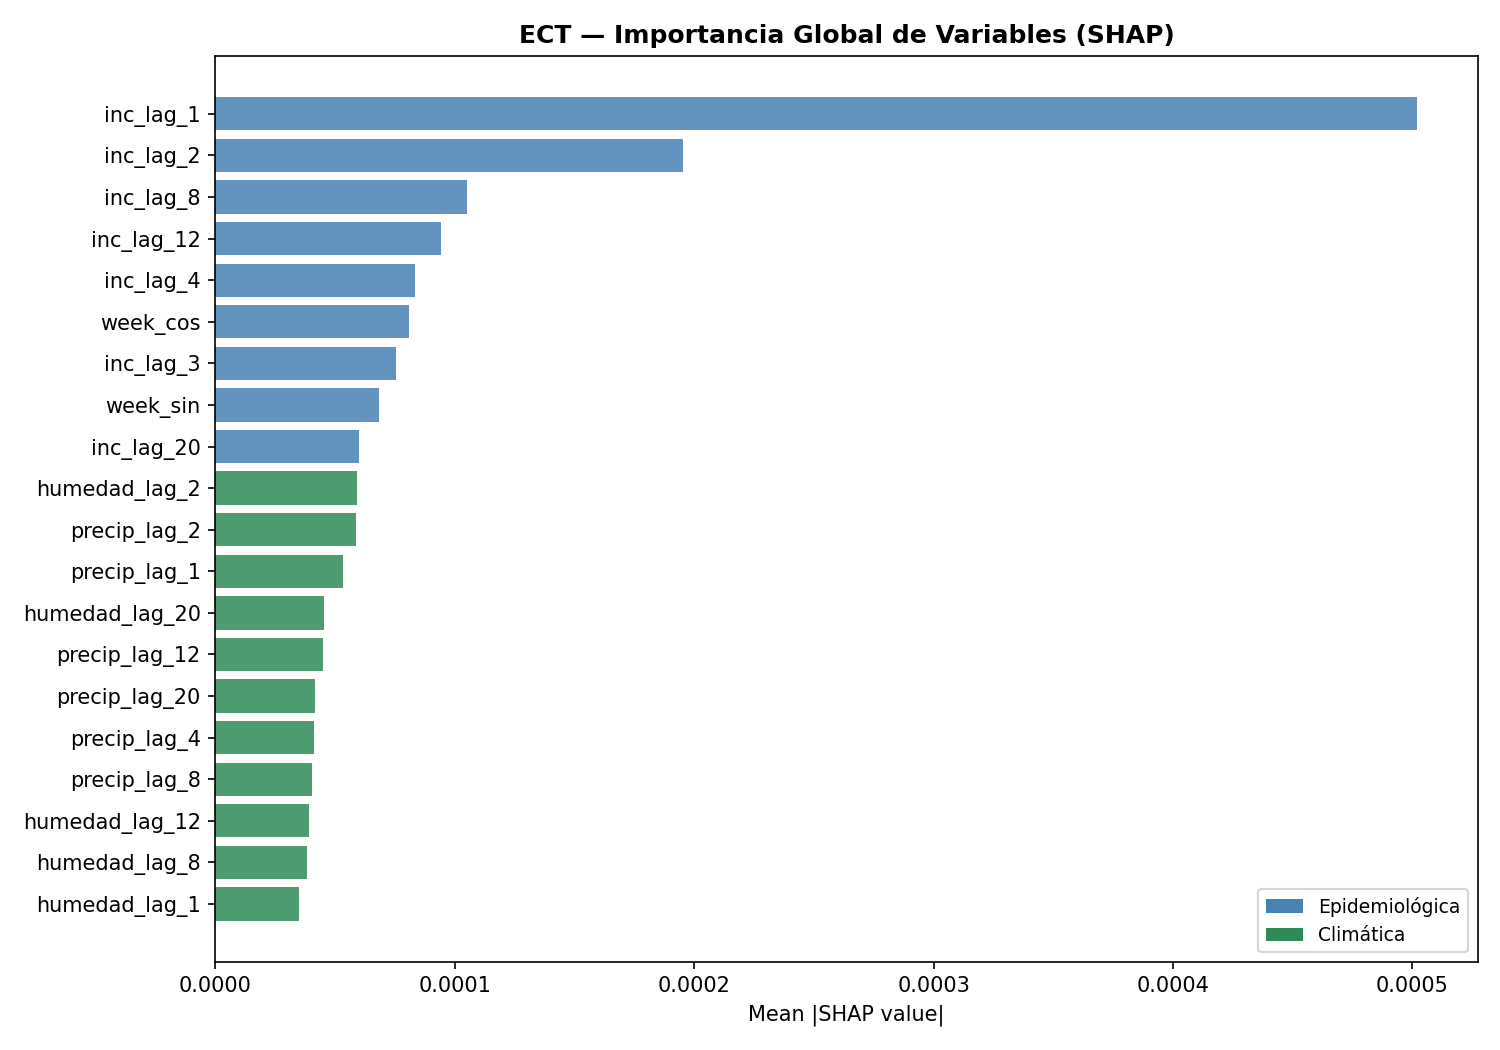

In [61]:
Image.open(f"{BASE_PATH}/ect_shap_importance.png")

El análisis de importancia global mediante SHAP revela que la arquitectura fundamenta su capacidad predictiva principalmente en la memoria endógena de la serie, donde los componentes autorregresivos de corto plazo (`inc_lag_1` e `inc_lag_2`) acumulan más del 38% del impacto neto del modelo. Las variables climáticas rezagadas de humedad y precipitación, junto con las variables cíclicas estacionales (`week_cos`, `week_sin`), actúan como moduladores secundarios esenciales que estabilizan las proyecciones a mediano plazo. Esta marcada jerarquía explica por qué el transformador exhibe un rendimiento sobresaliente en regiones con datos continuos y estables (como el Fold 3), pero enfrenta dificultades matemáticas y un sesgo negativo pronunciado en zonas periféricas como la Amazonía (Fold 4), donde la desconexión con el histórico nacional reduce la efectividad de los rezagos epidemiológicos globales.

## **11.13. Verificación de Archivos Generados**

Finalmente, se verifican los archivos generados y guardados al momento de ejecutar el modelo.

In [54]:
import os
print("=== ARCHIVOS GENERADOS EN", BASE_PATH, "===\n")
files = sorted(os.listdir(BASE_PATH))
for f in files:
    size = os.path.getsize(os.path.join(BASE_PATH, f))
    print(f"  {f:60} {size/1024:>8.1f} KB")

=== ARCHIVOS GENERADOS EN /home/moon/DEEP/PF/PF_DG/MODELOS/ECT_CV ===

  ect_best_params.csv                                               0.2 KB
  ect_best_params_seed_123.csv                                      0.1 KB
  ect_best_params_seed_2024.csv                                     0.1 KB
  ect_best_params_seed_42.csv                                       0.1 KB
  ect_cross_attention_heatmap.png                                 140.3 KB
  ect_inference_time.csv                                            0.5 KB
  ect_learning_curves.png                                          91.4 KB
  ect_metrics_by_seed.png                                         118.6 KB
  ect_metrics_by_year.png                                         120.0 KB
  ect_optuna_trials.csv                                             5.1 KB
  ect_predictions.csv                                            6699.6 KB
  ect_predictions_by_dept.png                                     689.3 KB
  ect_residuals.csv          